$$\text{SIM ID: 10263704 }$$
$$\text{NAME: Subathra Sundarbabu}$$
$$\text{DATE: 9 March 2026}$$
$$\text{CM3015 Machine Learning and Neural Networks}$$

<h3 style="text-align:center;">Binary Sentiment Classification on IMDB Reviews (DLWP Workflow)</h3>

# 1 Abstract

This project uses the IMDB movie review dataset to classify binary sentiment using the universal deep-learning process (Chollet, 2017). There are 25,000 training reviews and 25,000 test reviews in the dataset. The classes are evenly split between positive and negative, and the vocabulary is limited to the 10,000 most common words. In order to train fully connected dense neural networks, reviews were converted into 10,000-dimensional binary bag-of-words representations. A low-capacity baseline model was used as the starting point for an organised experimental progression, which was followed by an architecture that was purposefully over-parameterised to show overfitting behaviour, systematic regularisation, and hyperparameter tuning. The experiment went through a set order setting a baseline, scaling up the capacity to cause overfitting, single regularisation (L2 and Dropout), combined regularisation, and controlled hyperparameter tuning.

Although the overfitting model's training performance was nearly perfect, it showed an important difference between training and validation loss, supporting the impacts of memorisation. The training loss collapsed to effectively 0, but the validation loss rise significantly to 1.3821, showing that the model had low bias but high variance. While dropout improved classification accuracy through stochastic regularisation, L2 regularisation improved probability calibration and decreased overconfidence. The combined L2 + Dropout configuration demonstrated the most balanced bias–variance trade-off among regularised models. It achieved a peak validation accuracy of 88.50% at epoch 17 and maintained stable cross-entropy behaviour, with a final test accuracy of 87.04% confirms good out-of-sample generalisation compared with the baseline test accuracy of 85.96%.

The results show that just making the model bigger does not help generalisation. The overfitting experiment showed validation cross-entropy can rise while validation accuracy remains constant, indicating that the model is producing slowly overconfident probability estimates instead of improving its predictions. Instead, building reliable deep learning models requires targeted regularisation, careful overfitting analysis, and controlled scaling. This study shows how theoretical concepts of generalisation and optimisation result in real-world performance gains in text classification problems. However, using a binary bag-of-words representation does not take into account word order or contextual semantics, which limits the model's ability to capture deep structures of language.

# 2 Introduction

Sentiment analysis is a most important part of natural language processing. It involves identifying if a text is positive or negative. This project uses the IMDB movie review dataset to create a neural network classifier that predicts review sentiment. The study follows to the standard workflow of machine learning, moving from problem definition and baseline modeling to overfitting analysis and regularisation. The goal is not only to get high predictive accuracy, but also to learn how model capacity and regularisation affect how well a model generalises.

## 2.1 Problem Definition

The goal of this project is to use supervised learning to classify movie reviews into two groups positive and negative using universal workflow method (Chollet, 2017).

#### Input:
The input data is made up of text movie reviews that have been turned into binary bag-of-words representations with 10,000 dimensions. I turn each review into a number tensor that shows whether or not the most common words in the dataset are present. This changes text which is not structured into structured numbers that a neural network can use. This representation offers a high-dimensional sparse feature space that is appropriate for high-dimensional feature learning using dense neural networks, yet ignoring word order and contextual dependencies.

#### Output:
A single probability value between 0 and 1 that indicates the possibility that the review is positive is the output. This probability is generated in the last layer using a sigmoid activation function. Reviews are categorised as either positive or negative based on values greater than or equal to 0.5. The quality of probability calibration becomes important since the model produces probabilities rather than precise labels, especially when examining cross-entropy loss in overfitting trials. 

#### Problem Type:
Since each review falls into one of two sentiment categories that are mutually exclusive, this task is formulated as a binary classification task. By limiting the network to produce a single probability value that represents the likelihood of positive sentiment, this framing restricts the modeling technique. As a result, the assessment metrics and loss function selection are in line with binary classification ideas and are covered in later parts. From a statistical learning standpoint, the goal of this challenge is to minimise anticipated classification error under the empirical risk minimisation model by estimating a decision boundary in a high-dimensional feature space.

#### Assumptions:

The following basic assumptions support this modeling approach:
- It is possible to determine a review's sentiment from its textual content.
- There is enough information in the available dataset to identify significant trends.
- According to the stationarity assumption, the distribution of training data is typical of unseen data.
- The bag-of-words representation keeps enough lexical information for sentiment classification, yet lacking word order and contextual dependencies (a limitation discussed later).

These assumptions need to be verified by experimentation. Additionally, it is implicitly believed that the 10,000 word vocabulary limit preserves the most discriminative lexical characteristics while removing noise from uncommon phrases.

#### Learning Hypotheses:
In accordance with the universal method, two fundamental hypotheses are looked at:
- Given the input features word vectors, the output sentiment can be predicted.
- The dataset contains enough information for the model to be able to generalise instead of just memorise.

In the event that these theories are incorrect, even complex models would not be able to go above a random baseline. The bias–variance trade-off is implicitly related to these hypotheses high bias would arise from inadequate model capacity, whereas high variance would emerge from excessive flexibility without constraint.

#### Stationarity Assumption:
Because the IMDB dataset has a fixed train test split, stationarity holds by construction for this experiment, meaning that the training, validation, and test sets all have the same data distribution. Although monitoring for language drift over time would be necessary for the real-world deployment of a sentiment classifier, this assumption is satisfied here.

## 2.2 Importance of the Project

This study is significant because it applies the entire DLWP universal procedure to an actual text classification problem, going beyond prediction accuracy to investigate the relationship between regularisation and model capacity. This is clearly shown by the intentional overfitting experiment in Section 8 and the regularisation comparisons in Section 9. For example, the overfitting model's validation loss reached 1.3821 while its accuracy stayed at 88.22%, a difference that accuracy alone would hide. The research demonstrates the theoretical divide at the heart of contemporary deep learning practice by clearly separating between optimisation performance and generalisation performance.

In order to show the fundamental difference between underfitting and overfitting, the study purposefully scales model capacity to cause overfitting and then applies regularisation approaches. The results highlight how important hyperparameter tuning and rigorous evaluation procedures are to creating reliable, universal models. Additionally, the analysis shows that accuracy alone can be misleading because overconfident misclassifications can be revealed by cross-entropy loss, which may continue to rise even as a result of steady accuracy.

The insights gained about model scalability, regularisation, and evaluation are broadly applicable across machine learning domains, despite the relatively simple bag-of-words format. Thus, the project offers both conceptual knowledge of deep learning principles and hands-on modeling skills. However, the investigation of sequential language features that advanced versions like recurrent or transformer-based networks could capture is limited by the use of dense architectures and bag-of-words encoding.

# 3 Dataset Description

This research is based on the IMDB movie review dataset. Every characteristic of the IMDB dataset analysed in this section directly influences a particular modeling decision made subsequently in the workflow. An in-depth understanding of these attributes ensures that following preprocessing procedures and modeling choices are logically in line with the qualities of the data. Specifically, model capacity needs, optimisation stability, and generalisation behaviour are directly impacted by dataset scale, feature dimensionality, and class balance.

## 3.1 Load the Dataset

As stated in Deep Learning with Python (Chollet, 2017), TensorFlow is used to load the IMDB dataset using keras to begin the study for datasets. The dataset is restricted to the top 10,000 phrases in order to maintain important vocabulary features while lowering dimensionality. This vocabulary reduction may remove uncommon yet sentiment-informative words while maintaining high-frequency discriminative tokens and reducing computing costs.

In [1]:
# Import the required library
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.datasets import imdb
import tensorflow as tf
import numpy as np
import random
import os

To ensure the reproducibility of every result shown in this notebook, a fixed random seed of 42 is set before to data loading.

In [2]:
# random seed 42
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Load the dataset (code is followed from the book (Chollet, 2017))
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [4]:
# train data
print(train_data[0]) 

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [5]:
# train label
print(train_labels[0])

1


Each review is shown as a list of integers in the printed output. Instead than being raw text, these integers represent word indices in the dataset's vocabulary. Each index in this integer encoding corresponds to an order of frequency position in the corpus, representing a compressed symbol mapping of text. Positive attitude is expressed in the sample review, as shown by the accompanying label 1. This shows that the dataset is well-structured for supervised learning and has clearly defined input and output pairs.

## 3.2 Size

Examining the dataset's size to see if it is sufficient for training and evaluation comes next, once it has been loaded.

In [6]:
# Size of train data
len(train_data)

25000

In [7]:
# Size of test data
len(test_data)

25000

The output ensures that the dataset contains 25,000 training samples and 25,000 test samples. This slightly large sample size supports a hold-out validation approach instead of K-fold cross-validation. 50,000 marked reviews are available, which offers enough statistical power to train deep neural networks and produce accurate performance estimations. K-fold cross-validation is not necessary because the dataset size of 50,000 labelled samples is large enough to reduce variance in performance estimation.

## 3.3 Data Types

Vectorisation and tensor conversion cannot be done unless the data types are known.

In [8]:
# Type of the train data
type(train_data[0])

list

In [9]:
# Type of the train label
type(train_labels[0])

numpy.int64

The output shows that the sentiment label is stored as a NumPy integer numpy.int64, while each review is recorded as a Python list. This indicates to the fact that the input data is made up of integer sequences of varying length. These lists must then be converted into uniform-length vectors since neural networks require fixed-dimensional tensor inputs. Sequence length variability also suggests that raw sequences contain time information that will be lost during the conversion process to fixed-size bag-of-words vectors. At this point, confirming data types ensures that preprocessing methods can be used appropriately.

## 3.4 Class Distribution

Before training a classifier, it is important to check if the dataset is balanced across classes.

In [10]:
# Count class distribution
sentiment, count = np.unique(train_labels, return_counts=True)

In [11]:
# sentiment 0 or 1
sentiment

array([0, 1], dtype=int64)

In [12]:
# count of each sentiment value
count

array([12500, 12500], dtype=int64)

The outcome shows that the dataset contains 12,500 positive and 12,500 negative views. The complete balance of this distribution ensures that accuracy is a suitable primary evaluation criterion because there is no class imbalance that might affect performance measurements. Because each class's previous chance is equal in balanced binary classification, bias toward majority-class prediction is eliminated, making accuracy a reliable measure of expected error. Class weighting and resampling methods are not necessary because of the balanced dataset.

## 3.5 Origin

For sentiment classification research, the IMDB movie review dataset is a significant benchmark. TensorFlow's dataset repository makes it publicly accessible and includes 50,000 highly divided reviews that have been classified as either positive or negative (TensorFlow, 2024). The dataset is used to show basic deep learning concepts in Deep Learning with Python (Chollet, 2017), where it is also thoroughly explained. Because of its extensive use as a standard dataset, studies can be evaluated and repeated.

In order to ensure a balanced class distribution, the dataset was carefully selected to preserve equal representation of both positive and negative ratings. Because reviews are integer-encoded and already tokenized, they can be easily included into machine learning workflows. Tokenisation and index mapping were preprocessed by the dataset providers (Tensorflow, 2024). The dataset preserves the most informative features for classification while reducing noise from unusual tokens by restricting the vocabulary to the 10,000 most common terms. This preprocessing phase, however, creates high-dimensional sparse vectors that may raise the risk of overfitting in high-capacity dense networks by introducing a sparsity pattern in the feature space.

The IMDB dataset is perfectly suited for researching the trade-off between optimisation and generalisation in neural networks because to its size, balance, and individual labeling structure. While yet being computationally possible for controlled experimentation, it offers enough complexity to show overfitting behaviour. This dataset is especially appropriate for analysing optimisation dynamics, capacity scaling, and regularisation effects under controlled settings due to the combination of high-dimensional sparse input vectors with balanced class labels.

# 4 Measure of Success

A key component of the machine learning process is defining a precise success metric. If a model's performance is not measured with a suitable metric, it can not be effectively assessed or improved. The assessment metric that is selected for classification tasks needs to be in line with the problem's structure and represent the true prediction goal. Choosing an appropriate assessment measure and loss function is important for this project, which aims to accurately categorise movie reviews as either positive or negative. Additionally, analysing overfitting, probability calibration, and generalisation performance throughout the experimental workflow depends on the distinction between optimisation aims and assessment measures.

## 4.1 Evaluation Metric

Accuracy is chosen as the main evaluation criteria since the IMDB dataset is completely balanced between positive and negative ratings. The percentage of accurately classified predicts among all predictions is known as accuracy. A clear and understandable indicator of model performance is accuracy, which is calculated as the ratio of correctly identified examples to all predictions (Yenigun, 2023): 

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

where true positives, true negatives, false positives, and false negatives are indicated by the letters TP, TN, FP, and FN. Accuracy measures how frequently the predicted class matches the ground truth label by estimating the empirical classification error under a 0.5 decision threshold.

Because both classes contribute equally to the overall performance score in balanced classification situations like this dataset, accuracy is appropriate. Other metrics, like precision, recall, or F1-score, would be more appropriate if the dataset were unbalanced, but in this instance, accuracy consistently indicates predictive efficiency. Since the class prior probabilities are equal, accuracy is unaffected by majority-class dominance and accurately represents the expected misclassification risk. However, accuracy is insufficient for properly identify overfitting because it does not represent the confidence of predictions and may be constant even while probability calibration decreases.

## 4.2 Loss Function

Neural networks are not trained to directly optimise accuracy, even if accuracy is used to assess model performance. Rather, a distinct loss function that directs weight updates through backpropagation is used in training.

Binary cross-entropy was selected as the loss function for this binary classification task. The difference between the actual binary labels and the projected probability distribution is measured by binary cross-entropy. It is defined as (Raju, 2025):

$$
\text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]
$$

where yi represents the true label, Pi represents the predicted probability and N is the total number of samples. The negative log of a Binomial distribution is equivalent to binary cross-entropy from a probabilistic standpoint, which means that the model is trained by maximising the chance of the observed labels.

Binary cross-entropy encourages the model to generate accurately calibrated probability estimates by penalising confident inaccurate predictions more harshly than uncertain ones (Raju, 2025). Because of this, cross-entropy is sensitive to both classification accuracy and prediction confidence, which makes it especially helpful for identifying overconfident misclassifications. Binary cross-entropy is mathematically suitable and compatible with gradient-based optimisation since the network's final layer uses a sigmoid activation function to output probabilities in the range [0,1]. Training loss may get close to zero while validation cross-entropy rises during overfitting, suggesting that the model has attained low bias but large variance.

## 4.3 Why Training Loss and Evaluation Metric Differ

The fact that the evaluation metric and the loss function are not necessarily the same is a basic idea in machine learning. Because accuracy is not differentiable and depends on a single threshold usually 0.5, it cannot be directly optimised. To calculate gradients, neural networks need a smooth, differentiable objective function. Such a smooth objective is provided by binary cross-entropy, which maintains probabilistic interpretability while allowing gradient-based optimisation by backpropagation.

Therefore, in binary classification tasks, binary cross-entropy functions as an alternative objective that roughly corresponds to accuracy. Predicted probabilities grow more consistent with actual labels as cross-entropy decreases, which typically leads to increased classification accuracy. Empirical findings indicate a high correlation between the two, even though minimising cross-entropy does not ensure optimum accuracy at every training stage. Specifically, validation cross-entropy may rise as validation accuracy plateaus, indicating that the model is growing more confident without improving correctness.

The universal workflow concept is reflected in the division between optimisation minimising binary cross-entropy and evaluation maximising accuracy models are trained using a differentiable loss function, and task-relevant performance metrics are used to quantify success. This alignment ensures that significant increases in prediction performance result from optimisation improvements. As a result, both metrics are tracked during the experiment accuracy for evaluating the effectiveness of classification and cross-entropy to measure optimisation dynamics and calibration.

# 5 Evaluation Protocol

A reliable assessment process is important for tracking model performance throughout development once the success measure has been defined. The division of data and the measurement of generalisation performance are determined by an evaluation process. Performance estimates could be misleading because of overfitting or data leaking without the use of a structured validation strategy. Specifically, an optimistic biased estimate of generalisation error would arise from assessing a model on the same data used for optimisation.

Hold-out validation, K-fold cross-validation, and repeated K-fold validation are the three standard evaluation techniques described in the universal workflow (Chollet, 2017). The quantity of the dataset and the required level of performance estimation reliability are the primary indicators of which option is best. Because the IMDB dataset is sufficiently large, a hold-out validation approach is used in this research. This decision ensures that the variation of the performance estimate stays acceptable low given the high sample size by finding a compromise between statistical reliability and computational efficiency.

## 5.1 Hold-Out Validation

The available training data is divided into two subgroups for the hold-out validation method:
- A training set for model parameter optimisation
- A validation set for assessing the model's performance as it is being developed

The 25,000 sample initial training dataset is further split into an 80/20 split for this project. 80% goes toward training. 20% for validation. This ratio preserves enough validation samples to generate statistically significant performance estimates while providing enough training data for consistent parameter estimation. The validation set is used to track performance over epochs and identify overfitting, not for weight changes. Validation performance, not training performance, is the basis for model selection decisions like architectural scaling and regularisation tuning. By selecting models based on validation performance, the integrity of the final evaluation is maintained because information from the test set is not indirectly incorporated into the optimisation process.

Apart from the training-validation divide, a second test set of 25,000 reviews is kept for the final assessment. The test set is only used to check how well the model works in general, not to choose a model or adjust hyperparameters. Selection bias would be introduced by repeatedly evaluating the test set during development, which would boost stated performance.

This three-way division training, validation, and test ensures that the processes of optimisation, model selection, and final evaluation are distinct from one another.

## 5.2 Justification for Hold-Out Validation

The IMDB dataset's size and features support the choice to employ hold-out validation. With 25,000 training samples at hand, there is enough information to assign a significant validation subset without significantly lowering training capacity. The universal workflow states that hold-out validation is suitable in situations when there is a large amount of data since it offers a dependable and computationally effective way to estimate generalisation performance. (Chollet, 2017) 

Generally speaking, K-fold cross-validation is advised when hold-out estimates could be unstable and datasets are small. When exceptionally high evaluation precision is needed, iterated K-fold validation is employed. However, for huge datasets like IMDB, these methods are unnecessary and computationally more costly. Also, repeated cross-validation would greatly increase the time it takes to train high-capacity neural networks without giving this dataset size a proportional increase in estimate stability.

Additionally, keeping a distinct validation set makes it possible to clearly observe the trade-off between optimisation and generalisation. Overfitting is shown during experimentation when increases in training accuracy are accompanied by a decrease in validation performance. This difference between training and validation metrics is a practical sign that the model's variance is going up and its ability to generalise is going down. Thus, the systematic scaling and regularisation approach used in later parts is supported by this protocol.

The evaluation approach reduces the possibility of information leakage by maintaining an unchanged test set and restricting model selection choices to validation performance. This technique ensures that the final performance offers an objective assessment of the ability to generalise in the real world. The protocol follows best practices in machine learning by clearly separating optimisation, model selection, and final evaluation. This makes it easier to reproduce the results that are reported.

# 6 Data Preparation

The raw IMDB reviews need to be converted into numerical tensors that a neural network can understand before model training can start. A dense neural network that expects fixed-size inputs cannot be directly fed the original dataset, which encodes each review as a variable-length sequence of word indices. The preprocessing procedures required to transform review sequences into 10,000-dimensional vectors, translate labels into numeric forms that are compatible, and generate a validation subset for regulated model building are covered in this section. The design of preprocessing steps has a direct effect on the model's capacity needs, how well it optimises, and the chance of overfitting, especially in sparse feature spaces with many dimensions.

## 6.1 Vectorization Input Data

Each review in the IMDB dataset is a list of word indices, and the sequences are encoded with integers. The reviews are transformed into a binary bag-of-words representation since dense neural networks need a fixed-dimensional feature vector for every input. A matrix of shape (number of samples, 10000) is created by the vectorization function, with each row representing a review and each column representing a word index in the top 10,000 vocabulary. This change makes a high-dimensional sparse matrix, where most of the entries are zero because each review has a limited number of words. The word appears at least once in the review if it has a value of 1, and it is absent if it has a value of 0. This representation does not take into account term frequency, which means that using a word more than once does not make its feature value higher. This strategy follows to the preprocessing technique outlined by the book (Chollet, 2017).

In [13]:
# Vectorize the sequences (code is followed from the book (Chollet, 2017))
def vectorize(seq, dimension=10000):
    # Matrix filled with 0 
    matrix = np.zeros((len(seq), dimension))
    # go into each review and get the word indices
    for i, sequence in enumerate(seq):
        # position to 1 where the word appear
        matrix[i, sequence] = 1.
    return matrix

In [14]:
# vectorize input data (code is followed from the book (Chollet, 2017))
x_train = vectorize(train_data)
x_test = vectorize(test_data)

In [15]:
# x_train print
x_train

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])

In [16]:
# x_test print
x_test

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])

The outputs x_train and x_test verify that the data has been transformed into dense arrays of 0 and 1. One review stored as a binary feature vector over the 10,000-word vocabulary is represented by each row. By ensuring that every review has the same input shape, this transformation makes batch training with dense layers effective. The bag-of-words model captures powerful lexical signals that are frequently sufficient for sentiment classification in basic deep learning experiments, while removing word order and syntax. Sequential dependencies and contextual nuances in language are not captured by the model, despite the fact that this simplification lowers computing complexity and maintains optimisation. Dense fully connected layers with 10,000 input features result in a huge number of trainable parameters, increasing representational power but also increasing the risk of overfitting.

## 6.2 Vectorization Target Labels

In the IMDB dataset, the target labels are given as integer values 0 being negative and 1 being positive. These labels are transformed into NumPy arrays of type float32 for neural network training. This prevents type inconsistencies during tensor operations and ensures adherence with the binary cross-entropy loss function. Furthermore, using float32 ensures compatibility with TensorFlow's gradient computing pipeline and numerical stability. A same numerical format for training, validation, and test evaluation is produced by the conversion.

In [17]:
# Vectorizing target labels (code is followed from the book (Chollet, 2017))
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [18]:
# y_train
y_train

array([1., 0., 0., ..., 0., 1., 0.], dtype=float32)

The output shows that y_train is now a float32 array with just 0.0 and 1.0 values. This format readily aligns with binary cross-entropy optimisation and directly matches the probability output of a sigmoid final layer.

## 6.3 Validation Set Creation

A validation set is generated from the training data to track generalisation performance throughout training and help in model selection decisions. The first 5,000 samples from the vectorised training set are held aside for validation using a hold-out strategy, while the remaining data are used for training. The initial 25,000 training instances were split 80/20 in this way 20,000 for training and 5,000 for validation. To maintain proper input label pairing, the same split is applied to both input features and target labels. Selecting the first 5,000 samples does not cause systematic sampling bias because the provider shuffles the IMDB dataset. In order to reduce random fluctuations in performance monitoring between epochs, the 5,000-sample validation subset is large enough to provide reliable estimations of validation accuracy and cross-entropy.

In [19]:
# Training and validation split
x_val = x_train[:5000]
part_of_x_train = x_train[5000:]

In [20]:
# Training and validation split
y_val = y_train[:5000]
part_of_y_train = y_train[5000:]

This division produces four datasets with different functions x_val and y_val are only used to assess performance following each epoch, but part_of_x_train and part_of_y_train are used to change model weights during optimisation. In order to identify overfitting, compare different designs, and adjust regularisation hyperparameters without affecting the final test evaluation, this separation is important. The integrity of stated generalisation performance is maintained by keeping the model choice process separate from the final test evaluation by separating validation data from weight updates.

# 7 Baseline Model

In the universal workflow, creating a baseline model comes after the data has been prepared and the evaluation methodology has been set up. Demonstrating statistical power, or showing that the problem is learnable and that the model can outperform random guessing, is the goal of a baseline rather than achieving optimal performance. For upcoming scaling, overfitting, and regularisation techniques, this baseline acts as a point of reference. By establishing this reference, future expansions and regularisation techniques can be assessed in relation to a controlled, statistically valid starting point.

## 7.1 Baseline Model Design

The baseline model's capacity is purposefully limited. A sigmoid output layer comes after three hidden dense layers, each having eight units. In order to prevent excessive parameter growing and still have sufficient flexibility to extract significant patterns from the 10,000-dimensional input vectors, the architecture is narrow and shallow. The 10,000 input features lead to a significant parameter count in the first layer despite the short hidden layer size, highlighting the relationship between input dimensionality and model complexity. In order to create a more conservative starting point and ensure that the baseline creates a lower bound on performance that subsequent capacity-scaling tests may clearly overcome, eight units per layer were purposefully chosen below the DLWP standard architecture of 16 units (Chollet, 2017). During a forward pass, each Dense layer computes $ output = relu(dot(input, W) + b)$ , where the dot product of the input and weight matrix is summed with a bias term before being passed through ReLU activation (Chollet, 2017). The sigmoid output maps predictions to [0,1], representing positive sentiment probability.

In addition to providing a controlled starting point for analysing the optimisation generalisation trade-off, the small number of units limits representational capacity. In order to lower the possibility of extreme variance while still enabling the model to capture current lexical sentiment patterns, this architectural constraint purposefully generates mild bias. Subsequent tests can clearly show the effects of increasing model capacity due to this strategy.

## 7.2 Baseline Model

The Keras Sequential API is used to implement the basic neural network in the way shown below.

In [21]:
# Import the required libraries
from tensorflow.keras import models
from tensorflow.keras import layers

In [22]:
# Baseline Model with the dense layers
tf.random.set_seed(42)
baseline = models.Sequential()
baseline.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
baseline.add(layers.Dense(8, activation='relu'))
baseline.add(layers.Dense(8, activation='relu'))
baseline.add(layers.Dense(1, activation='sigmoid'))
baseline.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 80008     
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 8)                 72        
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 80161 (313.13 KB)
Trainable params: 80161 (313.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The network has 80,161 trainable parameters, according to the model summary. Even though there are only eight units in each hidden layer, the first dense layer has 80,008 parameters in that layer alone since it links 10,000 input features to eight neurons. This highlights an important understanding when working with high-dimensional inputs, even compact dense systems can have significant parameter counts. The parameter-to-sample ratio stays below 1:1 with 80,161 trainable parameters and 20,000 training samples, which reduces but does not completely remove the possibility of overfitting. One sigmoid-activated neuron in the last layer generates a probability output appropriate for binary classification.

## 7.3 Model Compilation

The model is compiled using the Adam optimizer, binary cross-entropy loss, and accuracy as the evaluation metric after the architecture has been designed.

In [23]:
# Compile the model
baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

The book suggests RMSprop as a secure default however, Adam is chosen for its adaptive moment estimation, which provides more reliable convergence in the high-dimensional sparse bag-of-words input space used in this study(Chollet, 2017). The Adam optimizer is chosen for deep network training because to its long-lasting and flexible learning rate characteristics. In high-dimensional optimisation environments like those created by sparse bag-of-words inputs, Adam's adaptive learning rate technique promotes steady convergence. Binary cross-entropy enables gradient-based optimisation and is consistent with the sigmoid output layer. During training, accuracy is one of the monitoring metrics.

## 7.4 Training

Training and validation split is used to train the model across 15 epochs with a batch size of 512.

In [24]:
# train the model
train = baseline.fit(part_of_x_train, part_of_y_train, epochs=15, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/15


40/40 [==============================] - 1s 14ms/step - loss: 0.6419 - accuracy: 0.5335 - val_loss: 0.5631 - val_accuracy: 0.6292
Epoch 2/15
40/40 [==============================] - 0s 6ms/step - loss: 0.5116 - accuracy: 0.7690 - val_loss: 0.4890 - val_accuracy: 0.8322
Epoch 3/15
40/40 [==============================] - 0s 5ms/step - loss: 0.4400 - accuracy: 0.8957 - val_loss: 0.4740 - val_accuracy: 0.8472
Epoch 4/15
40/40 [==============================] - 0s 6ms/step - loss: 0.3980 - accuracy: 0.9269 - val_loss: 0.4662 - val_accuracy: 0.8638
Epoch 5/15
40/40 [==============================] - 0s 6ms/step - loss: 0.3660 - accuracy: 0.9455 - val_loss: 0.4594 - val_accuracy: 0.8740
Epoch 6/15
40/40 [==============================] - 0s 5ms/step - loss: 0.3424 - accuracy: 0.9574 - val_loss: 0.4676 - val_accuracy: 0.8728
Epoch 7/15
40/40 [==============================] - 0s 6ms/step - loss: 0.3242 - accuracy: 0.9649 - val_loss: 0.4676 - val_accuracy: 0.8750
Epoch 8/15
40/40 

From an initial validation accuracy of 62.92% in the first epoch to a peak validation accuracy of 87.50% at epoch 7, the model rapidly improves during training. After this, though, training accuracy keeps rising until 98.53% but validation performance progressively decreases. Meanwhile, after epoch 4, validation loss starts to rise. Growing confidence on training samples without corresponding improvement on unseen data is indicated by this increase in validation cross-entropy despite ongoing training loss reduction.

Early-stage overfitting is marked by this pattern. The model's generalisation performance does not increase proportionally even though it keeps optimising the training objective. Even with a relatively small-capacity model, memorising behaviour can be seen in the divergence between training and validation loss. Widening loss divergencece shows that the model can increasingly memorise training-specific patterns due to the high-dimensional input space, even with a small number of hidden units.

## 7.5 Results

### Model Performance

The training history was analysed across all epochs. Both final-epoch metrics and the epoch with the highest validation accuracy are reported for comparison.

In [25]:
# store the history in a dictionary
dictionary_baseline = train.history

In [26]:
# print the values
print("Baseline Training Accuracy:", dictionary_baseline['accuracy'][-1])
print("Baseline Validation Accuracy:", dictionary_baseline['val_accuracy'][-1])

Baseline Training Accuracy: 0.9853000044822693
Baseline Validation Accuracy: 0.8672000169754028


In [27]:
# print the values
print("Baseline Training Loss:", dictionary_baseline['loss'][-1])
print("Baseline Validation Loss:", dictionary_baseline['val_loss'][-1])

Baseline Training Loss: 0.2332681566476822
Baseline Validation Loss: 0.5858206748962402


In [28]:
# print the values
print("Baseline Best Epoch:", int(np.argmax(dictionary_baseline['val_accuracy'])) + 1)
print("Baseline Best Validation Accuracy:", float(dictionary_baseline['val_accuracy'][int(np.argmax(dictionary_baseline['val_accuracy'])) + 1 - 1]))
print("Baseline Best Validation Loss:", float(dictionary_baseline['val_loss'][int(np.argmax(dictionary_baseline['val_accuracy'])) + 1 - 1]))

Baseline Best Epoch: 7
Baseline Best Validation Accuracy: 0.875
Baseline Best Validation Loss: 0.4676433205604553


Strong optimisation capacity is indicated by the training accuracy, which is almost perfect (98.53%). Nonetheless, the apparent difference in performance between training and validation validates that the model's generalisation is not as good. This proves that the baseline model is statistically strong but already shows overfitting. While the significantly increased validation loss suggests rising variation, the very low training loss (0.233) indicates strong optimisation on the training data, but the widening validation gap indicates increasing variance.

### Learning Curves

This behaviour is further shown by the learning curves.

In [29]:
# Import the required library
import matplotlib.pyplot as plt

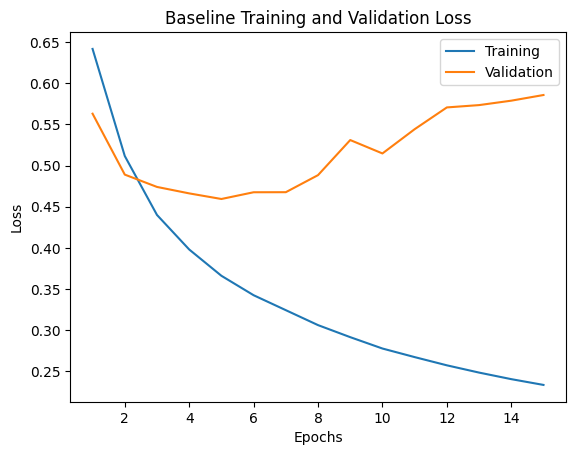

In [30]:
# Training and Loss plot 
plt.plot(range(1, len(dictionary_baseline['loss']) + 1), dictionary_baseline['loss'] ,label='Training')
plt.plot(range(1, len(dictionary_baseline['loss']) + 1), dictionary_baseline['val_loss'], label='Validation')
plt.title('Baseline Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

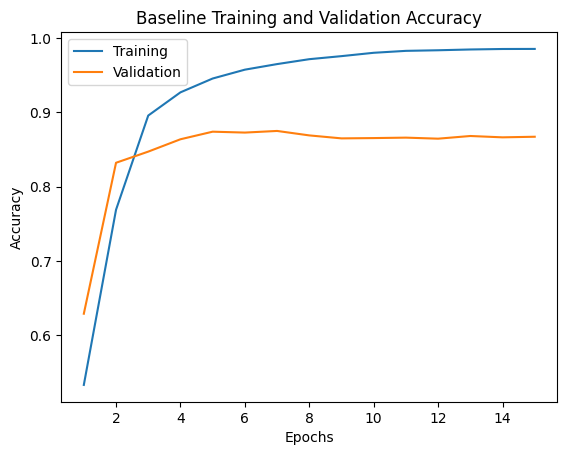

In [31]:
# Training and Accuracy plot
plt.plot(range(1, len(dictionary_baseline['loss']) + 1), dictionary_baseline['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_baseline['loss']) + 1), dictionary_baseline['val_accuracy'], label='Validation')
plt.title('Baseline Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Training loss steadily decreases, but validation loss starts to rise after the first few epochs, according to the loss curve. In the same way, validation accuracy plateaus and even declines, whereas training accuracy keeps getting better. The tension between optimisation and generalisation is clearly shown by this difference. The significance of validation monitoring is further supported by the early peak in validation accuracy around epochs 7, which indicates that the ideal stopping point occurs before the full convergence of training loss.

### Test Performance

For completeness, the baseline model is evaluated on the held-out test set to estimate generalisation. Model development decisions are guided by validation performance, while the final trained model is evaluated on the held-out test set to estimate generalisation.

In [32]:
# Test the baseline model
test = baseline.evaluate(x_test, y_test)
print("Test Accuracy:", test[1])
print("Test Loss:", test[0])

782/782 [==============================] - 1s 1ms/step - loss: 0.5893 - accuracy: 0.8596
Test Accuracy: 0.8596000075340271
Test Loss: 0.5893402099609375


The model significantly exceeds random classification 0.50, as confirmed by the test accuracy, indicating statistical strength. The generalisation gap is quantified and significant variance is confirmed by the difference between training accuracy 98.53% and test accuracy 85.96%. The model is starting to overfit, as evidenced by the divergence between training and validation loss and accuracy the test result provides an additional generalisation estimate. Because of this, the baseline model serves as a suitable benchmark for the achieving success stage of the process. In order to justify later capacity scaling to purposefully increase overfitting before using regularisation techniques, the baseline model creates a statistically correct but variance-prone reference point.The model can only learn the strongest and most generalisable lexical signals due to the 8-unit layers restricted parameter count, which prevents it from memorising individual training cases. This is why mild overfitting rather than severe overfitting is seen. The model generalises very well but has not completely used the training signal, indicating a little underfitting tendency consistent with its purposefully modest capacity. This is seen in the small difference between training accuracy (0.9853) and validation accuracy (0.8672).

# 8 Overfitting Model

The universal approach suggests purposefully creating an over-capacity model to cross the line into overfitting after generating a baseline model with statistical power (Chollet, 2017). This stage serves a diagnostic role by assisting in determining how training length and model capability impact the optimisation generalisation balance. The experiment reveals overfitting behaviour through the divergence between training and validation performance, which is caused by purposefully creating a much larger network and training it for more epochs. In the following step, regularisation and hyperparameter modification are initiated using this overfitting reference model. Because cross-entropy loss is sensitive to overconfident incorrect predictions even when the 0.5 threshold accuracy is stable, this experiment also shows how accuracy alone may hide decreasing probability quality.

## 8.1 Overfitting Model Design

The overfitting model is meant to outperform the baseline model in terms of representational capability. The network is extended to a deep architecture with gradually decreasing layer 512 -> 256 -> 128 -> 64 -> 32, in place of tiny hidden layers 8 units. The model can easily memorise training data because to this design, which significantly expands the number of trainable parameters. The model has sufficient degrees of freedom to fit sparse high-dimensional word-presence patterns that might not generalise because the first layer dominates model complexity of 5.12 million weights.

The design makes overfitting happen even faster for a structural reason. The early wide layers 512, 256 can easily find and remember sparse word-presence patterns directly from the 10,000-dimensional input. As activations move through different layers, the network uses a lot of non-linear transformations to compress these very specific training-data representations. By the time signals get to the 32-unit, the network has already learned how to encode word co-occurrence patterns that are specific to training into a compact form that the final layer can separate with almost complete confidence. This makes a good memorisation pipeline because the wide layers aggressively overfit the input space, and the 32-unit makes this even stronger by keeping only the most training-specific signals. The baseline model, on the other hand, has 8-unit layers that never develop the early representational capacity needed to make these memorised pathways. This is why overfitting happens more slowly there.

The model is trained for 35 epochs, which not only improves capacity but also raises the risk of overfitting. The workflow states that adding layers, making layers larger, and training for longer periods of time can all lead to overfitting. Training and validation curves should be monitored to determine when validation performance decreases (Chollet, 2017). This experiment directly follows to that idea.

## 8.2 Overfitting Model

The following is how the high-capacity model is put into practice.

In [33]:
# Overfitting Model with the dense layers
tf.random.set_seed(42)
overfit = models.Sequential()
overfit.add(layers.Dense(512, activation='relu', input_shape=(10000,)))
overfit.add(layers.Dense(256, activation='relu'))
overfit.add(layers.Dense(128, activation='relu'))
overfit.add(layers.Dense(64, activation='relu'))
overfit.add(layers.Dense(32, activation='relu'))
overfit.add(layers.Dense(1, activation='sigmoid'))
overfit.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 512)               5120512   
                                                                 
 dense_5 (Dense)             (None, 256)               131328    
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 5295105 (20.20 MB)
Trainable params: 529

A significant increase in complexity is confirmed by the model summary the network has 5,295,105 trainable parameters about 20.2 MB. The first layer alone 512 contributes the most, generating around five million parameters. This is a major increase in trainable weights over the baseline which was about 80k parameters. The network has more than enough freedom to fit the training data very closely due to this purposefully excessive capacity growth.

## 8.3 Model Compilation

To ensure a fair comparison, the compilation parameters are maintained in line with the baseline model. The impact of capacity and training time is separated by using the same optimiser and loss function.

In [34]:
# Compile the model
overfit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Adam is still suitable for effective optimisation, accuracy is tracked to evaluate classification performance across training, validation, and test sets, and binary cross-entropy is in line with the sigmoid output.

## 8.4 Training

The same training and validation split is used to train the model over 35 epochs. The number of training epochs is intentionally increased to 35 in order to increase overfitting behaviour and clearly expose the divergence between optimisation and generalisation.

In [35]:
# train the model
train_overfit = overfit.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 47ms/step - loss: 0.3834 - accuracy: 0.8385 - val_loss: 0.3021 - val_accuracy: 0.8814
Epoch 2/35
40/40 [==============================] - 2s 41ms/step - loss: 0.1602 - accuracy: 0.9445 - val_loss: 0.3006 - val_accuracy: 0.8874
Epoch 3/35
40/40 [==============================] - 2s 41ms/step - loss: 0.0625 - accuracy: 0.9811 - val_loss: 0.5480 - val_accuracy: 0.8546
Epoch 4/35
40/40 [==============================] - 2s 41ms/step - loss: 0.0218 - accuracy: 0.9941 - val_loss: 0.5561 - val_accuracy: 0.8774
Epoch 5/35
40/40 [==============================] - 2s 41ms/step - loss: 0.0046 - accuracy: 0.9988 - val_loss: 0.6624 - val_accuracy: 0.8812
Epoch 6/35
40/40 [==============================] - 2s 40ms/step - loss: 8.8730e-04 - accuracy: 0.9998 - val_loss: 0.7580 - val_accuracy: 0.8812
Epoch 7/35
40/40 [==============================] - 2s 40ms/step - loss: 2.4531e-04 - accuracy: 1.0000 - val_loss: 0.8110 - val_accuracy: 0.8842
Epoch

A quick optimisation process can be seen in the training log. Training accuracy increases toward 1.0 and training loss decreases toward zero by epoch 10. For example, the model had reached near-perfect training performance accuracy of 1.0000 by epoch 7, suggesting that it is successfully memorising the training data.

On the other hand, although validation accuracy remains generally constant throughout epochs, the validation loss increases steadily. In the early stages, validation loss starts at approximately 0.30 in the first epoch and increases steadily thereafter. The model grows more certain of its predictions on the training data, but its probability estimates on unknown validation samples worsen over time. This behaviour is a clear sign of overfitting and poor calibration. Even if overall accuracy only slightly increases, a small number of confident errors can result in a significant increase in validation loss in cross-entropy terms. With predicted probabilities growing more extreme without improving correctness on unseen samples, this pattern suggests increasing variance and decreasing calibration..

This pattern shows the tension between optimisation and generalisation that is highlighted in the workflow a big model can nearly completely optimise the training objective, but the final solution may not be the most generalisable.


## 8.5 Results

### Model Performance

All epochs of the training history were examined. To show how long-term training impacts generalisation, both the final-epoch metrics and the epoch with the best validation performance are provided. The ideal validation point is reached early, even while validation accuracy remains relatively steady. After that, validation loss grows rapidly, suggesting that probability calibration is getting worse even as threshold-based accuracy is consistent.

In [36]:
# store the history in dictionary
dictionary_overfit = train_overfit.history

In [37]:
# Print the values
print("Overfit Training Accuracy:", dictionary_overfit['accuracy'][-1])
print("Overfit Validation Accuracy:", dictionary_overfit['val_accuracy'][-1])

Overfit Training Accuracy: 1.0
Overfit Validation Accuracy: 0.8822000026702881


In [38]:
# Print the values
print("Overfit Training Loss:", dictionary_overfit['loss'][-1])
print("Overfit Validation Loss:", dictionary_overfit['val_loss'][-1])

Overfit Training Loss: 2.3867139020694594e-07
Overfit Validation Loss: 1.382093906402588


In [39]:
# Print the values
print("Overfit Best Epoch:", int(np.argmax(dictionary_overfit['val_accuracy'])) + 1)
print("Overfit Best Validation Accuracy:", float(dictionary_overfit['val_accuracy'][int(np.argmax(dictionary_overfit['val_accuracy'])) + 1 - 1]))
print("Overfit Best Validation Loss:", float(dictionary_overfit['val_loss'][int(np.argmax(dictionary_overfit['val_accuracy'])) + 1 - 1]))

Overfit Best Epoch: 2
Overfit Best Validation Accuracy: 0.8873999714851379
Overfit Best Validation Loss: 0.3005661964416504


These findings clearly show overfitting. While the significantly greater validation loss suggests that this memorised solution does not transfer well to unseen data, the training loss nearing 0 indicates near-perfect memorisation. The growing loss gap indicates that while model confidence is growing on the training set, generalisation gains are not keeping pace.

### Learning Curves

The learning curves are plotted.

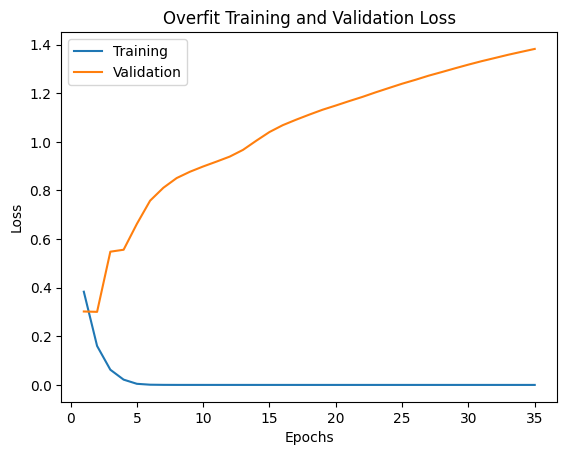

In [40]:
# Training and Loss plot 
plt.plot(range(1, len(dictionary_overfit['loss']) + 1), dictionary_overfit['loss'], label='Training')
plt.plot(range(1, len(dictionary_overfit['loss']) + 1), dictionary_overfit['val_loss'], label='Validation')
plt.title('Overfit Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

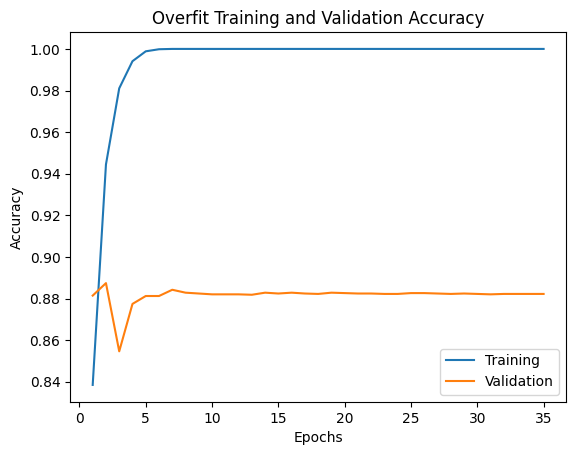

In [41]:
# Training and Accuracy plot
plt.plot(range(1, len(dictionary_overfit['loss']) + 1), dictionary_overfit['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_overfit['loss']) + 1), dictionary_overfit['val_accuracy'], label='Validation')
plt.title('Overfit Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The best indicator of overfitting is the loss curve, which shows that validation loss increases gradually over epochs while training loss rapidly collapses and stays close to zero. While validation accuracy stays in the 0.88 range, training accuracy saturates at 1.0. This shows that the classifier still accurately predicts a large number of validation samples, but its probability outputs are becoming more extreme and unreliable, which raises the cross-entropy loss. To put it another way, the model is actively making mistakes, which is severely punished under binary cross-entropy.

### Test Performance

The model is  evaluated on the independent test set to estimate generalisation. However, model development conclusions are mainly from validation behaviour.

In [42]:
# Test the overfitting model
overfit_test = overfit.evaluate(x_test, y_test)
print("Overfit Test Accuracy:", overfit_test[1])
print("Overfit Test Loss:", overfit_test[0])

782/782 [==============================] - 3s 4ms/step - loss: 1.5299 - accuracy: 0.8654
Overfit Test Accuracy: 0.8654000163078308
Overfit Test Loss: 1.5298770666122437


Even if validation accuracy is used to determine which epoch is the best epoch, this criterion is not particularly useful in this situation. Over the majority of epochs, validation accuracy stays relatively constant at 0.88, but validation loss rises significantly and rapidly. Even while accuracy by itself does not clearly reflect this decrease, the best calibrated and most stable model appears very early in training, as evidenced by the lowest validation loss at epoch 2.

The sharply increasing validation loss already indicates poor probability calibration and overfitting. The high test loss is consistent with this behaviour and confirms reduced generalisation despite similar accuracy. This is the exact goal of the overfitting experiment from a workflow standpoint it shows that longer training times and higher capacity can result in near-perfect optimisation, but they can also cause unstable generalisation behavior. The next step, which involves using regularisation techniques dropout and L2 and adjusting hyperparameters to lower the loss divergence while preserving high classification accuracy, is strongly justified by this overfitting reference.

# 9 Regularisation

The universal workflow then moves on to regularisation after purposefully building an over-capacity model and seeing clear overfitting behaviour. Regularisation techniques limit the complexity of the model so that the network learns generalisable patterns instead of learning unique characteristics of the training data. This study evaluates two popular strategies dropout and L2 weight regularisation. Various techniques are used by each method to combat overfitting dropout introduces probabilistic feature suppression that forces durability and redundancy in learned representations, whereas L2 discourages excessive weights. In order to assign performance variations to the regularisation strategy rather than architectural modifications, the subsequent subsections analyse each technique separately using the same high-capacity architecture.

## 9.1 L2 Regularisation Only

### 9.1.1 L2 Regularised Model Design

The deep architecture used in the overfitting experiment 512 -> 256 -> 128 -> 64 -> 32 is still present in the L2-regularised model. In order to maintain the model's high flexibility, L2 regularisation is applied to each dense layer with a penalty factor of 0.001. A term equal to the squared size of the weights is added to the loss function by L2 regularisation. In theory, this makes the network less dependent on a few very large weights and more prone to distribute importance among numerous intermediate weights. This reduces the chance that the model will create weak decision limits that fit training noise.

### 9.1.2 L2 Regularised Model

To ensure comparability, the L2 regularised model keeps the same deep architecture as the overfitting model. The addition of kernel_regularizer=regularizers.l2(0.001) to each Dense layer is the only change.

In [43]:
# Import the required library
from tensorflow.keras import models, layers, regularizers

In [44]:
# L2 regularised model
tf.random.set_seed(42)
l2_model = models.Sequential()
l2_model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(10000,)))
l2_model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
l2_model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
l2_model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
l2_model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
l2_model.add(layers.Dense(1, activation='sigmoid'))
l2_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 512)               5120512   
                                                                 
 dense_11 (Dense)            (None, 256)               131328    
                                                                 
 dense_12 (Dense)            (None, 128)               32896     
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dense_14 (Dense)            (None, 32)                2080      
                                                                 
 dense_15 (Dense)            (None, 1)                 33        
                                                                 
Total params: 5295105 (20.20 MB)
Trainable params: 529

According to the model summary, the number of parameters is still 5,295,105, which is the same as in the unregularised overfitting model. It is important to note that L2 regularisation changes the optimisation goal by punishing big weights, not by lowering the number of parameters. Without regularisation, it can easily memorise uncommon word patterns because the first layer alone has almost five million parameters. Instead of learning sharp, highly specific decision boundaries, the model is pushed to learn smoother, more diffused representations of emotion by applying L2 penalties to all dense layers.

### 9.1.3 Compilation

To make sure that differences in performance are due to regularisation and not optimisation settings, the model is built using the same optimisation configuration as earlier tests before training.

In [45]:
# Compile the model
l2_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Keras automatically adds the L2 penalty to the overall training loss even though the provided loss function is binary cross-entropy. Therefore, the weight decay term and cross-entropy add up to the optimisation goal. As a result, higher training loss values relative to the unregularised model do not always indicate worse classification performance rather, they are a reflection of the extra regularisation penalty that was applied during optimisation.

### 9.1.4 Training

The same batch size and validation split as earlier studies are used to train the L2-regularised model over 35 epochs.

In [46]:
# train the model
train_l2 = l2_model.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 51ms/step - loss: 1.1753 - accuracy: 0.8393 - val_loss: 0.7840 - val_accuracy: 0.8822
Epoch 2/35
40/40 [==============================] - 2s 44ms/step - loss: 0.6103 - accuracy: 0.9254 - val_loss: 0.6283 - val_accuracy: 0.8808
Epoch 3/35
40/40 [==============================] - 2s 43ms/step - loss: 0.4766 - accuracy: 0.9340 - val_loss: 0.6286 - val_accuracy: 0.8680
Epoch 4/35
40/40 [==============================] - 2s 42ms/step - loss: 0.4236 - accuracy: 0.9399 - val_loss: 0.5600 - val_accuracy: 0.8756
Epoch 5/35
40/40 [==============================] - 2s 44ms/step - loss: 0.3760 - accuracy: 0.9520 - val_loss: 0.5860 - val_accuracy: 0.8704
Epoch 6/35
40/40 [==============================] - 2s 44ms/step - loss: 0.3341 - accuracy: 0.9646 - val_loss: 0.5640 - val_accuracy: 0.8760
Epoch 7/35
40/40 [==============================] - 2s 44ms/step - loss: 0.2972 - accuracy: 0.9778 - val_loss: 0.6085 - val_accuracy: 0.8742
Epoch 8/35
40

Epoch 11 shows an anomalous spike in validation loss (0.8112) accompanied by a drop in validation accuracy to 0.8338, likely caused by a short Adam optimiser step with an unlucky gradient update on this batch partition the model recovers in subsequent epochs, suggesting this was a numerical instability rather than a generalisation failure. Beyond this instability spike, L2 punishes weight magnitude but does not stop the model from gradually assigning increasing confidence to training-specific patterns this is a type of slow overfitting that accuracy alone does not show. This is why there is a gradual drift in validation loss across subsequent epochs.

L2 regularisation typically maintains validation loss within a reasonable range for the majority of training when compared to the unregularised overfitting model, showing greater stability in probability outputs. A consistent optimisation trajectory under the fixed 35-epoch schedule is suggested by the last epochs in this run remaining stable, with training accuracy remaining at 1.0 and validation accuracy remaining in the 0.87 range.

### 9.1.5 Results

#### Model Performance

The final training and validation metrics are compiled after the L2-regularised model has been trained for 35 epochs. These final values offer a concise view of the generalisation behaviour and optimisation quality. Importantly, the training loss for regularised models includes both the cumulative L2 penalty and the binary cross-entropy factor, so the loss numbers should be carefully known.

In [47]:
# store the history in dictionary
dictionary_l2 = train_l2.history

In [48]:
# Print the results
print("L2 Training Accuracy:", dictionary_l2['accuracy'][-1])
print("L2 Validation Accuracy:", dictionary_l2['val_accuracy'][-1])

L2 Training Accuracy: 0.9999499917030334
L2 Validation Accuracy: 0.8726000189781189


In [49]:
# Print the results
print("L2 Training Loss:", dictionary_l2['loss'][-1])
print("L2 Validation Loss:", dictionary_l2['val_loss'][-1])

L2 Training Loss: 0.07768136262893677
L2 Validation Loss: 0.6138890385627747


In [50]:
# Best epoch based on highest validation accuracy
print("L2 Best Epoch:", int(np.argmax(dictionary_l2['val_accuracy'])) + 1)
print("L2 Best Validation Accuracy:", float(dictionary_l2['val_accuracy'][int(np.argmax(dictionary_l2['val_accuracy']))]))
print("L2 Best Validation Loss", float(dictionary_l2['val_loss'][int(np.argmax(dictionary_l2['val_accuracy']))]))

L2 Best Epoch: 1
L2 Best Validation Accuracy: 0.8822000026702881
L2 Best Validation Loss 0.7839680910110474


At the last epoch (epoch 35), the L2 model outputs training accuracy = 0.9999 and validation accuracy = 0.8726, as well as training loss = 0.0777 and validation loss = 0.6139. The findings show that L2 stabilises probability outputs under the set training schedule since they hold true during late epochs.

#### Learning Curves

Because learning curves show when overfitting starts and how stable the model is throughout training, they offer a more comprehensive picture than a single final result. Learning curves provide a clearer picture of stability across epochs and help identify whether validation behaviour remains consistent or shows late-stage instability.

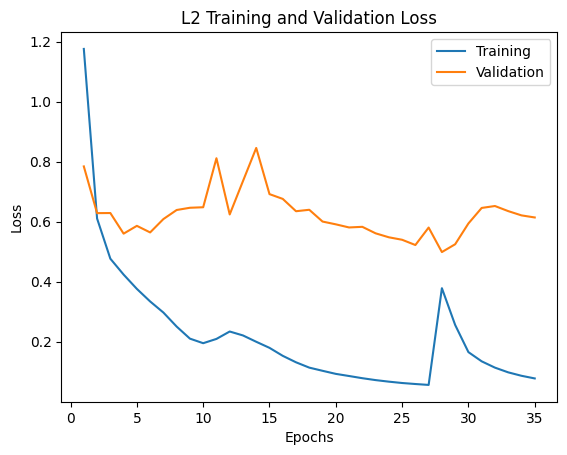

In [51]:
# Training and Loss plot 
plt.plot(range(1, len(dictionary_l2['loss']) + 1), dictionary_l2['loss'], label='Training')
plt.plot(range(1, len(dictionary_l2['loss']) + 1), dictionary_l2['val_loss'], label='Validation')
plt.title('L2 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

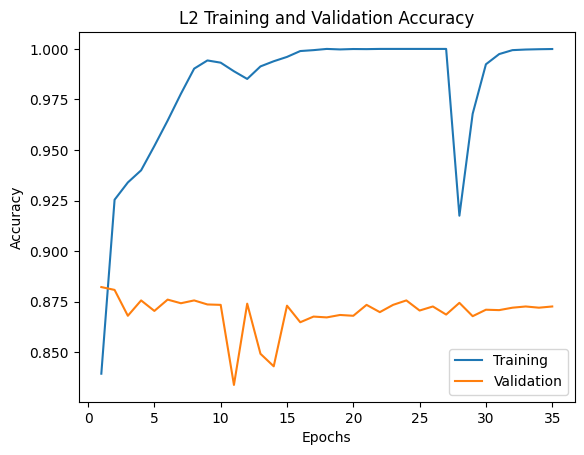

In [52]:
# Training and Accuracy plot
plt.plot(range(1, len(dictionary_l2['loss']) + 1), dictionary_l2['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_l2['loss']) + 1), dictionary_l2['val_accuracy'], label='Validation')
plt.title('L2 Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Given the size of the network, the curves indicate that training accuracy increases toward 1.0. Validation loss is comparatively controlled over the majority of epochs when compared to the unregularised model. Validation loss remains comparatively stable in the later epochs, indicating that L2 regularisation maintains probability stability even under the fixed 35-epoch schedule. Compared to the unregularised model, the validation loss remaining within a defined range suggests better probability stability, even if validation accuracy varies slightly. A smaller and more consistent validation loss suggests that L2 reduces confident mistakes and produces a more generalisable decision surface since cross-entropy heavily punishes confident incorrect predictions.

#### Test Performance

For completeness, the model is evaluated on the independent test set using the final-epoch weights. Because no early stopping was used, the test results reflect the end-of-training state rather than the best validation epoch. Since the test set was not used to inform training choices, test outcomes are the most accurate indicator of how well the model should perform on unknown data. In comparison to the unregularised overfit model, high generalisation for L2 should show competitive test accuracy as well as a significantly lower test loss.

In [53]:
# test the L2 model
l2_test = l2_model.evaluate(x_test, y_test)
print("L2 Model Test Accuracy:", l2_test[1])
print("L2 Model Test Loss:", l2_test[0])

782/782 [==============================] - 3s 3ms/step - loss: 0.6281 - accuracy: 0.8679
L2 Model Test Accuracy: 0.8678799867630005
L2 Model Test Loss: 0.6280947923660278


Using the final epoch weights, the L2 model achieved test accuracy = 0.8679 and test loss = 0.6281. Strong generalisation and somewhat consistent probability calibration under L2 regularisation are indicated by this.

## 9.2 Dropout Regularisation Only

### 9.2.1 Dropout Model Design

By adding randomness to training, dropout regularisation reduces overfitting. At each update step, a certain percentage of activations is set to zero. As a result, the model is forced to develop redundant and spread representations rather than depending on a few number of highly predictive neurons. Dropout is especially useful in deep dense networks trained on bag-of-words vectors because it issues with adaptation between layers, reducing the dependence of the acquired emotion signal on memorisation of particular feature combinations. In order to adjust the memorisation behaviour shown in the overfitting model, a severe regularisation setting known as dropout at rate 0.5 is applied after each hidden dense layer in this experiment.

### 9.2.2 Dropout Model

In order to separate the impact of dropout, dropout layers are added after each dense hidden layer while maintaining the same architecture as the overfitting model. This ensures that variations in dropout's training behaviour, not changes in the number of parameters or network depth, will be reflected in any performance changes.

In [54]:
# Dropout Model
tf.random.set_seed(42)
dropout_model = models.Sequential()
dropout_model.add(layers.Dense(512, activation='relu', input_shape=(10000,)))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(256, activation='relu'))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(128, activation='relu'))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(64, activation='relu'))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(32, activation='relu'))
dropout_model.add(layers.Dropout(0.5))
dropout_model.add(layers.Dense(1, activation='sigmoid'))
dropout_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 512)               5120512   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_17 (Dense)            (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_18 (Dense)            (None, 128)               32896     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_19 (Dense)            (None, 64)               

The model summary confirms that dropout does not decrease the amount of learnable weights by displaying the same parameter count of 5,295,105 as the overfitting model. Dropout changes the way certain weights are trained instead. The effective network is always a new sub network since half of the activations are eliminated at each training stage. This increases the difficulty of memorisation and forces the model to store sentiment in a more reliable manner that is independent of any one pathway. However, training can begin more slowly than in non-dropout models since strong dropout also makes optimisation noisier.

### 9.2.3 Compilation 

To maintain fair comparisons and ensure that variations may be assigned to dropout rather than optimisation configuration, the dropout model is built using the same parameters as before tests.

In [55]:
# Compile the model
dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

By using binary cross-entropy, optimisation can be sure to punish not just bad class predictions but also incorrect probability estimations. Because dropout can increase decision robustness while still producing probability distributions that change in confidence over time, this becomes particularly important for dropout models.

### 9.2.4 Training

Similar to previous models, the dropout model is trained for 35 epochs with the same batch size and validation split. The objective is to see if dropout lessens the overfitting behavior that was previously seen training loss decreasing while validation loss progressively grows.

In [56]:
# Train the model
train_dropout = dropout_model.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 59ms/step - loss: 0.6895 - accuracy: 0.5428 - val_loss: 0.5949 - val_accuracy: 0.8140
Epoch 2/35
40/40 [==============================] - 2s 43ms/step - loss: 0.4435 - accuracy: 0.8099 - val_loss: 0.2901 - val_accuracy: 0.8848
Epoch 3/35
40/40 [==============================] - 2s 43ms/step - loss: 0.2620 - accuracy: 0.9114 - val_loss: 0.3159 - val_accuracy: 0.8786
Epoch 4/35
40/40 [==============================] - 2s 43ms/step - loss: 0.1756 - accuracy: 0.9422 - val_loss: 0.3016 - val_accuracy: 0.8910
Epoch 5/35
40/40 [==============================] - 2s 44ms/step - loss: 0.1089 - accuracy: 0.9672 - val_loss: 0.4052 - val_accuracy: 0.8880
Epoch 6/35
40/40 [==============================] - 2s 44ms/step - loss: 0.0670 - accuracy: 0.9815 - val_loss: 0.4724 - val_accuracy: 0.8882
Epoch 7/35
40/40 [==============================] - 2s 45ms/step - loss: 0.0416 - accuracy: 0.9883 - val_loss: 0.5748 - val_accuracy: 0.8824
Epoch 8/35
40

The training log has a clear dropout pattern validation accuracy reaches the high 0.88 range early epoch 2 to 3, and performance rapidly rises after the first epoch. Dropout reaches high validation accuracy quickly and keeps it relatively stable, but the steadily increasing validation loss suggests growing more confident errors later in training. The model may still generate gradually confidence probability on a subset of the occurrences, though, as evidenced by the significantly greater validation loss later in training. Binary cross-entropy severely punishes these confident errors. Because accuracy is threshold-based and cross-entropy evaluates confidence calibration, it is possible for accuracy to stay high as loss increases. Particularly, the lowest validation loss occurs very early (epoch 3), while later epochs keep similar validation accuracy but with much higher validation loss, indicating worsening calibration over time.

### 9.2.5 Results

#### Model Performance

In order to measure both optimisation and generalisation at the end of the training schedule, final training and validation metrics are extracted after training.

In [57]:
# store the history in dictionary
dictionary_dropout = train_dropout.history

In [58]:
# Print the results
print("Dropout Training Accuracy:", dictionary_dropout['accuracy'][-1])
print("Dropout Validation Accuracy:", dictionary_dropout['val_accuracy'][-1])

Dropout Training Accuracy: 0.9987000226974487
Dropout Validation Accuracy: 0.8809999823570251


In [59]:
# Print the results
print("Dropout Training Loss:", dictionary_dropout['loss'][-1])
print("Dropout Validation Loss:", dictionary_dropout['val_loss'][-1])

Dropout Training Loss: 0.0062069096602499485
Dropout Validation Loss: 1.1713722944259644


In [60]:
# Best epoch based on highest validation accuracy
print("Dropout Best Epoch:", int(np.argmax(dictionary_dropout['val_accuracy'])) + 1)
print("Dropout Best Validation Accuracy:", float(dictionary_dropout['val_accuracy'][int(np.argmax(dictionary_dropout['val_accuracy']))]))
print("Dropout Best Validation Loss:", float(dictionary_dropout['val_loss'][int(np.argmax(dictionary_dropout['val_accuracy']))]))

Dropout Best Epoch: 4
Dropout Best Validation Accuracy: 0.890999972820282
Dropout Best Validation Loss: 0.30159232020378113


The dropout model obtains training accuracy = 0.9987 and validation accuracy = 0.8810 using final epoch weights, with training loss = 0.0062 and validation loss = 1.1714. The validation loss is significantly higher than in the L2 setup, even though the validation accuracy is still high. This shows that while the model properly classifies the majority of samples, binary cross-entropy severely restricts some very confident incorrect predictions.

#### Learning Curves

Checking if dropout lowers overfitting reduced divergence or whether overfitting persists later in training due to growing validation loss can be done by plotting the loss and accuracy curves.

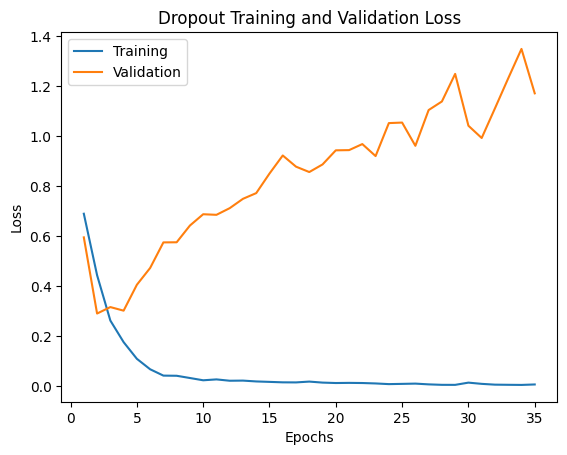

In [61]:
# Training and Loss plot 
plt.plot(range(1, len(dictionary_dropout['loss']) + 1), dictionary_dropout['loss'], label='Training')
plt.plot(range(1, len(dictionary_dropout['loss']) + 1), dictionary_dropout['val_loss'], label='Validation')
plt.title('Dropout Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

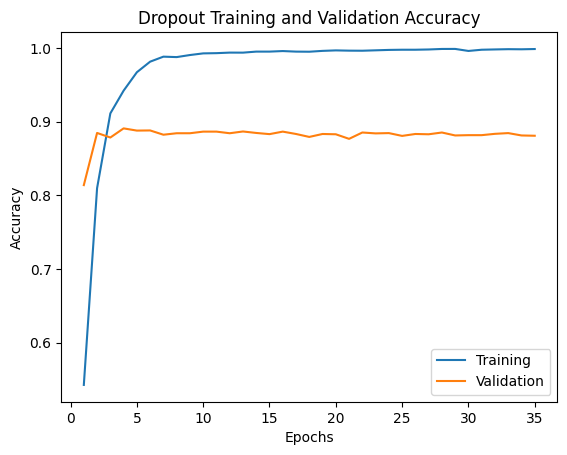

In [62]:
# Training and Accuracy plot
plt.plot(range(1, len(dictionary_dropout['loss']) + 1), dictionary_dropout['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_dropout['loss']) + 1), dictionary_dropout['val_accuracy'], label='Validation')
plt.title('Dropout Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The dropout lessens the memorisation behaviour observed in the unregularised model, as training accuracy rises significantly but validation accuracy remains mostly unchanged. The fact that the validation loss trend is still high, however, suggests that dropout might not be enough to stop the model from generating overconfident probability estimates throughout extended training. This supports the idea that while dropout increases robustness, additional constraints such L2 can still be necessary to maintain probability confidence.

#### Test Performance

Finally, the unseen test set is used to assess the dropout model. Regardless of training and validation feedback, this provides the final generalisation estimate.

In [63]:
# Test the dropout model
dropout_test = dropout_model.evaluate(x_test, y_test)
print("Dropout Test Accuracy:", dropout_test[1])
print("Dropout Test Loss:", dropout_test[0])

782/782 [==============================] - 3s 4ms/step - loss: 1.2839 - accuracy: 0.8726
Dropout Test Accuracy: 0.8725600242614746
Dropout Test Loss: 1.2839348316192627


The dropout model obtains test accuracy = 0.8726 and test loss = 1.2839 on the independent test set. In comparison to the combined model, the comparatively high test loss shows that dropout increases classification accuracy but does not completely maintain probability calibration. Dropout improves decision boundary resilience, but it may still result in overconfident predictions on some samples.

## 9.3 Combined L2 + Dropout

### 9.3.1 Combined L2 + Dropout Model Design

The L2-only and dropout-only experiments prevent overfitting in different ways. L2 does this by making it less likely for weights to be too large which makes decision surfaces smoother and less extreme, and dropout does this by adding random noise during training, which makes the model less dependent on adapted feature pathways. A combined model is therefore advantageous as it can leverage both effects simultaneously weight magnitude control to reduce excessively confident probability outputs, and representation durability to prevent the network from memorising particular training patterns. In this experiment, the architecture remains unchanged from the overfitting model to facilitate a controlled comparison, while adding L2 0.001 into each Dense layer and Dropout 0.5 next to each hidden layer.

### 9.3.2 Combined L2 + Dropout Model 

This combined model uses L2 (0.001) and Dropout (0.5) together to keep the high-capacity network from overfitting. L2 limits the size of weights, and dropout stops adaptation by randomly turning off activations during training. The architecture is the same as the overfitting model so that any differences in performance are due to regularisation and not changes in capacity.

In [64]:
# Combined model
tf.random.set_seed(42)
combined_model = models.Sequential()
combined_model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(10000,)))
combined_model.add(layers.Dropout(0.5))
combined_model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model.add(layers.Dropout(0.5))
combined_model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model.add(layers.Dropout(0.5))
combined_model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model.add(layers.Dropout(0.5))
combined_model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model.add(layers.Dropout(0.5))
combined_model.add(layers.Dense(1, activation='sigmoid'))
combined_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 512)               5120512   
                                                                 
 dropout_5 (Dropout)         (None, 512)               0         
                                                                 
 dense_23 (Dense)            (None, 256)               131328    
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_24 (Dense)            (None, 128)               32896     
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_25 (Dense)            (None, 64)               

The summary shows that the number of parameters is still 5,295,105, which means that combining L2 and dropout does not lower the model's capacity. It just changes how it learns. This model has two constraints that happen at the same time:

- L2 constantly penalises large weight magnitudes, which makes it harder for the network to make very sharp boundaries that fit noise.
- Dropout randomly takes away half of the activations while training, which makes the model learn extra, spread-out sentiment cues instead of relying on a few neuron pathways that are very good at predicting things.

This design directly addresses the behaviour seen in the overfitting model, which is perfect training accuracy with a validation loss that rises sharply overconfidence in unseen samples. The combined regularisation is meant to cut down on both memorisation and mistakes that are too sure of themselves.

### 9.3.3 Compilation

The combined model is built using the same optimizer adam and the same main loss function binary_crossentropy to make sure that all the experiments are fair. This keeps the optimisation settings the same, so any changes in performance are due to regularisation and not to different training settings.

In [65]:
# compile the model
combined_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

The code claims to use binary cross-entropy, but the combined model's effective loss includes both Binary Cross Entropy and the L2 penalty terms from each Dense layer. This is important for understanding the combined model's loss values should be higher than those of the dropout-only model because the objective has an extra regularisation cost. So, evaluation should look at both accuracy and loss. Loss includes the effects of penalty and probability calibration, not just correctness at a 0.5 threshold.

### 9.3.4 Training

The model is trained for 35 epochs with the same batch size 512 and the same split for validation. The goal is to see if combined regularisation reduces the generalisation gap and makes validation performance more stable compared to settings with only L2 and only dropout.

In [66]:
# train the model
train_combined = combined_model.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 55ms/step - loss: 1.6796 - accuracy: 0.5453 - val_loss: 1.2021 - val_accuracy: 0.8274
Epoch 2/35
40/40 [==============================] - 2s 47ms/step - loss: 0.9364 - accuracy: 0.8256 - val_loss: 0.7194 - val_accuracy: 0.8842
Epoch 3/35
40/40 [==============================] - 2s 46ms/step - loss: 0.6635 - accuracy: 0.9085 - val_loss: 0.6478 - val_accuracy: 0.8844
Epoch 4/35
40/40 [==============================] - 2s 46ms/step - loss: 0.5456 - accuracy: 0.9332 - val_loss: 0.6152 - val_accuracy: 0.8792
Epoch 5/35
40/40 [==============================] - 2s 47ms/step - loss: 0.4716 - accuracy: 0.9464 - val_loss: 0.6309 - val_accuracy: 0.8840
Epoch 6/35
40/40 [==============================] - 2s 47ms/step - loss: 0.4296 - accuracy: 0.9568 - val_loss: 0.6653 - val_accuracy: 0.8802
Epoch 7/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4040 - accuracy: 0.9640 - val_loss: 0.6703 - val_accuracy: 0.8758
Epoch 8/35
40

A unique regularised learning pattern may be seen in the training record. Early epochs 1–5 show a sharp increase in validation accuracy from 0.8274 to approximately 0.8840, suggesting that the model picks up generalisable emotion features fast even in the face of L2 limitations and dropout noise. Training accuracy steadily rises into the 0.98 range over subsequent epochs, but it never reaches 1.0, which is in line with the idea that perfect memorisation is limited by strong regularisation.

One important finding is that validation accuracy is not reduced to zero but instead stays comparatively steady in the 0.87 range, indicating that combined regularisation prevents excessive memorisation. Although the model remains correct on the majority of validation samples, there are still probability-confidence effects binary cross entropy discourages confident incorrect predictions and the L2 penalty is still present in the loss, as shown by the fluctuation validation loss that tends upward in later epochs. Compared to the unregularised overfitting model, where validation loss increases rapidly and constantly, this behaviour is still far more stable.

### 9.3.5 Results

#### Model Performance

Final training and validation metrics represent endpoint performance following training. Both accuracy and loss are presented to capture correctness and stability since regularisation changes the probability confidence and loss definition.

In [67]:
# store the history in dictionary
dictionary_combined = train_combined.history

In [68]:
# Print the results
print("Combined Training Accuracy:", dictionary_combined['accuracy'][-1])
print("Combined Validation Accuracy:", dictionary_combined['val_accuracy'][-1])

Combined Training Accuracy: 0.9840999841690063
Combined Validation Accuracy: 0.8715999722480774


In [69]:
# Print the results
print("Combined Training Loss:", dictionary_combined['loss'][-1])
print("Combined Validation Loss:", dictionary_combined['val_loss'][-1])

Combined Training Loss: 0.3041701912879944
Combined Validation Loss: 0.7057851552963257


In [70]:
# Best epoch based on highest validation accuracy
print("Combined Best Epoch:", int(np.argmax(dictionary_combined['val_accuracy'])) + 1)
print("Combined Best Validation Accuracy:", float(dictionary_combined['val_accuracy'][int(np.argmax(dictionary_combined['val_accuracy']))]))
print("Combined Best Validation Loss:", float(dictionary_combined['val_loss'][int(np.argmax(dictionary_combined['val_accuracy']))]))

Combined Best Epoch: 17
Combined Best Validation Accuracy: 0.8849999904632568
Combined Best Validation Loss: 0.7005494832992554


The combined model achieves training accuracy = 0.9841 and validation accuracy = 0.8716 using final epoch weights, with training loss = 0.3042 and validation loss = 0.7058. The validation loss is significantly decreased, but the validation accuracy is slightly poorer than in the dropout-only model. Given that the model maintains competitive classification accuracy while making fewer extremely confident wrong predictions, this suggests improved probability stability.

#### Learning Curves

Evidence of generalisation behaviour over time can be found in learning curves. In comparison to the unregularised overfit model, the combined model is expected to produce less divergence between training and validation curves.

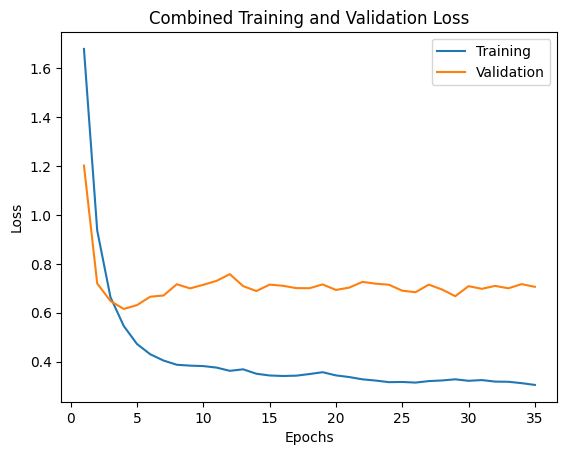

In [71]:
# Training and Loss plot
plt.plot(range(1, len(dictionary_combined['loss']) + 1), dictionary_combined['loss'], label='Training')
plt.plot(range(1, len(dictionary_combined['loss']) + 1), dictionary_combined['val_loss'], label='Validation')
plt.title('Combined Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

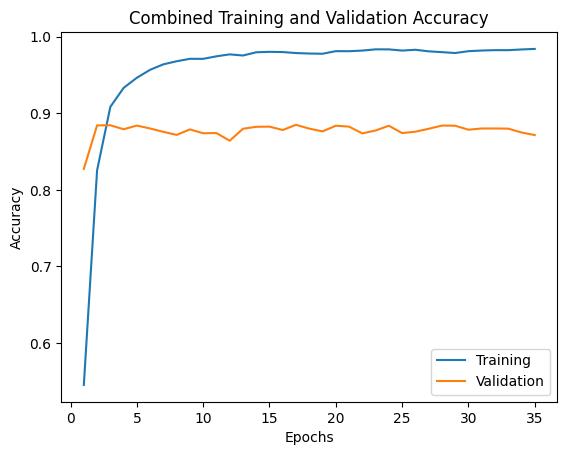

In [72]:
# Training and Accuracy plot
plt.plot(range(1, len(dictionary_combined['accuracy']) + 1), dictionary_combined['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_combined['accuracy']) + 1), dictionary_combined['val_accuracy'], label='Validation')
plt.title('Combined Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Regularisation effectively discourages pure memorisation, as the accuracy curves show that the model keeps improving on training data without decreasing validation accuracy. Although it may fluctuate because of dropout noise and the constant L2 penalty, the loss curves show that validation loss does not increase rapidly as in the overfit model. Overall, the combined curves point to a controlled trade-off in order to achieve a more stable generalisation profile, the model loses some training fit training accuracy less than 1.0.

#### Test Performance

In order to estimate real generalisation, the model is lastly tested once on the test set. The test set offers the most objective assessment of deployment performance since it is not used for training decisions.

In [73]:
# Test the combined model
combined_test = combined_model.evaluate(x_test, y_test)
print("Combined Test Accuracy:", combined_test[1])
print("Combined Test Loss:", combined_test[0])

782/782 [==============================] - 3s 4ms/step - loss: 0.7196 - accuracy: 0.8704
Combined Test Accuracy: 0.8704000115394592
Combined Test Loss: 0.7196051478385925


The combined model obtains test accuracy = 0.8704 and test loss = 0.7196 on the independent test set. The significantly lower test loss suggests more stable and accurately calibrated probability outputs, even though the test accuracy is extremely close to the dropout-only model. This suggests that overconfident predictions are successfully reduced while maintaining good classification performance when L2 regularisation and dropout are combined.

## 9.4 Analysis of Regularisation Models

Regularisation aims to manage model variance while maintaining competitive training accuracy to ensure strong generalisation on unseen data. The high-capacity dense network in this project showed signs of overfitting. This was clear when training performance quickly reached perfection while validation loss went up. So, to test regularisation, we used two signals that worked together cross-entropy loss and accuracy. All of the models in this section were trained for a set 35-epoch schedule without any checkpoints. This means that the final epoch weights are the same as the test results that were reported. Model evaluation shows the final trained state, while validation curves show how well a model generalises. In all models, the best validation performance was seen in the early epochs. This was especially true for the dropout-only and combined configurations. In later epochs, however, there were small changes because the training was fixed and there was no early stopping.

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Model</th>
      <th>Train Acc</th>
      <th>Val Acc</th>
      <th>Val Loss</th>
      <th>Test Acc</th>
      <th>Test Loss</th>
      <th>Best Val Acc</th>
      <th>Best Epoch<br>(by Val Acc)</th>
      <th>Val Loss<br>(at Best Val Acc)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>L2 Only</td>
      <td>0.9999</td>
      <td>0.8726</td>
      <td><b>0.6139</b></td>
      <td>0.8679</td>
      <td>0.6281</td>
      <td>0.8822</td>
      <td>1</td>
      <td>0.7840</td>
    </tr>
    <tr>
      <td>Dropout Only</td>
      <td>0.9987</td>
      <td><b>0.8810</b></td>
      <td>1.1714</td>
      <td>0.8726</td>
      <td>1.2839</td>
      <td><b>0.8910</b></td>
      <td>4</td>
      <td><b>0.3016</b></td>
    </tr>
    <tr>
      <td>Combined (L2 + Dropout)</td>
      <td>0.9841</td>
      <td>0.8716</td>
      <td>0.7058</td>
      <td>0.8704</td>
      <td>0.7196</td>
      <td>0.8850</td>
      <td>17</td>
      <td>0.7005</td>
    </tr>
  </tbody>
</table>

At the last epoch, the L2-only model had a stable validation accuracy of 0.8726 and a test accuracy of 0.8679. At epoch 1, the best validation accuracy of 0.8822 was reached. This means that L2 regularisation converges quickly but has trouble getting better after that on the fixed 35-epoch schedule. The run has some instability spikes in the middle of training, especially at epoch 11, when the validation loss shot up to 0.8112 before going back down. In this case, L2 gives lower loss values than dropout-only. However, since L2 loss includes the weight-penalty term, loss magnitudes should be seen more as a measure of training objective stability than as a pure calibration metric.

The dropout-only model has the highest final validation accuracy of 0.8810 and the highest test accuracy of 0.8726 of the three regularised models. At epoch 4, it had the best validation accuracy of 0.8910 and the lowest validation loss of 0.3016, which was the best epoch across all three models. But its final epoch validation loss of 1.1714 and test loss of 1.2839 are much higher than the combined setup. This trend indicates that dropout improves classification accuracy but may lead to unstable or overly confident probability estimates for certain samples, as binary cross-entropy imposes significant penalties on confident incorrect predictions.

The Combined L2 + Dropout model has the best generalisation behaviour when using the final-epoch method. It achieves a validation accuracy of 0.8716 and a test accuracy of 0.8704. The validation loss is 0.7058 and the test loss is 0.7196, which is much lower than the dropout-only model. The dropout-only model has a higher final validation accuracy of 0.8810, but its test loss of 1.2839 shows that it is generating overconfident probability estimates, which binary cross-entropy heavily penalises. The best validation accuracy of 0.8850 was reached at epoch 17. This means that the combined regularisation takes longer to converge but gives more stable probability estimates over time. The combination setup achieves a better bias–variance balance by using dropout to stop feature co-adaptation and L2 to limit weight magnitude at the same time.

### 9.4.1 Model Selection for HyperTuning

The Combined (L2 + Dropout) model offers the most possible trade-off under the fixed 35-epoch training period. Among the regularised models, it maintains end of training loss values significantly lower than the dropout only model. It achieves competitive validation accuracy of 0.8716 while maintaining substantially lower test loss of 0.7196 compared to dropout only 1.2839. The test accuracy observed later confirms that this selection decision generalises well, rather than informing it. Dropout-only achieves the highest final validation accuracy of 0.8810, but its test and validation loss significantly increases over training, suggesting that even with good threshold based accuracy, probability outputs become less well-behaved. Although L2-only produces somewhat accurate results and relatively steady behaviour, it falls short of the combined model's final test accuracy. Under a fixed 35-epoch training without early stopping, the Combined model demonstrates greater stability across epochs, whereas the Dropout-only model is highly sensitive to training duration and shows sharp peak decrease.

The combined model is selected as the beginning point for additional hyperparameter optimisation as a result of these variables. The test set is just used as an independent generalisation estimate for reporting it is not used to guide model selection or tuning decisions.

# 10 Hyperparameter Tuning

This part uses hyperparameter tuning to fine-tune the regularisation strength while maintaining a consistent network capacity, having chosen the Combined L2 + Dropout setup as the optimal regularisation baseline. To keep the experiment under control, the model architecture is purposefully kept constant across all tuning runs. Any variations in performance may be assigned to the tuned hyperparameters rather than extra depth, width, or parameter count. Here, we focus on two hyperparameters L2 weight decay strength which penalises big weights and encourages smoother decision boundaries and dropout rate which regulates feature suppression and decreases adaptation. To ensure consistency and fairness across trials, every tuned model is trained using the same optimiser Adam, loss function binary cross-entropy with additional L2 penalty terms automatically added by Keras, training schedule 35 epochs, batch size 512, and validation split. The interaction between weight decay and stochastic regularisation can be investigated in a controlled way by simultaneously varying the L2 penalty strength and the dropout rate across three configurations, which constitutes a multi-dimensional search over the regularisation hyperparameter space.

## 10.1 Combined Model 1 - Dropout 0.3 + L2 0.001

This experiment assesses whether learning efficiency and generalisation improve when dropout is reduced from 0.5 to 0.3 while the L2 penalty stays fixed at 0.001. From a conceptual standpoint, reducing dropout means that more activations are available every update step since less stochastic noise is introduced during training. This may enable the model to converge more quickly and more immediately understand valuable sentiment cues. However, if the residual L2 penalty is insufficient, reducing dropout may raise the risk of memorisation because it also serves as a powerful defense against co-adaptation in high-capacity dense networks. Thus, while still using weight decay to regulate excessive weights, this run evaluates the trade-off between representational capacity during optimisation and stability from stochastic regularisation.

In [74]:
# Combined model 1 with hypertuning
tf.random.set_seed(42)
combined_model_1 = models.Sequential()
combined_model_1.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(10000,)))
combined_model_1.add(layers.Dropout(0.3))
combined_model_1.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model_1.add(layers.Dropout(0.3))
combined_model_1.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model_1.add(layers.Dropout(0.3))
combined_model_1.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model_1.add(layers.Dropout(0.3))
combined_model_1.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
combined_model_1.add(layers.Dropout(0.3))
combined_model_1.add(layers.Dense(1, activation='sigmoid'))
combined_model_1.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 512)               5120512   
                                                                 
 dropout_10 (Dropout)        (None, 512)               0         
                                                                 
 dense_29 (Dense)            (None, 256)               131328    
                                                                 
 dropout_11 (Dropout)        (None, 256)               0         
                                                                 
 dense_30 (Dense)            (None, 128)               32896     
                                                                 
 dropout_12 (Dropout)        (None, 128)               0         
                                                                 
 dense_31 (Dense)            (None, 64)               

In [75]:
# Compile the model
combined_model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [76]:
# train the model
train_combined1 = combined_model_1.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 55ms/step - loss: 1.3602 - accuracy: 0.7559 - val_loss: 0.8363 - val_accuracy: 0.8838
Epoch 2/35
40/40 [==============================] - 2s 48ms/step - loss: 0.7132 - accuracy: 0.9090 - val_loss: 0.6817 - val_accuracy: 0.8768
Epoch 3/35
40/40 [==============================] - 2s 48ms/step - loss: 0.5459 - accuracy: 0.9316 - val_loss: 0.6345 - val_accuracy: 0.8782
Epoch 4/35
40/40 [==============================] - 2s 48ms/step - loss: 0.4610 - accuracy: 0.9473 - val_loss: 0.6067 - val_accuracy: 0.8800
Epoch 5/35
40/40 [==============================] - 2s 48ms/step - loss: 0.4075 - accuracy: 0.9578 - val_loss: 0.6633 - val_accuracy: 0.8764
Epoch 6/35
40/40 [==============================] - 2s 47ms/step - loss: 0.3817 - accuracy: 0.9704 - val_loss: 0.8097 - val_accuracy: 0.8430
Epoch 7/35
40/40 [==============================] - 2s 47ms/step - loss: 0.3726 - accuracy: 0.9732 - val_loss: 0.6933 - val_accuracy: 0.8744
Epoch 8/35
40

In [77]:
# store the history in dictionary
dictionary_combined1 = train_combined1.history

In [78]:
# Print the results
print("Combined 1 Training Accuracy:", dictionary_combined1['accuracy'][-1])
print("Combined 1 Validation Accuracy:", dictionary_combined1['val_accuracy'][-1])

Combined 1 Training Accuracy: 0.9916999936103821
Combined 1 Validation Accuracy: 0.8736000061035156


In [79]:
# Print the results
print("Combined 1 Training Loss:", dictionary_combined1['loss'][-1])
print("Combined 1 Validation Loss:", dictionary_combined1['val_loss'][-1])

Combined 1 Training Loss: 0.22683364152908325
Combined 1 Validation Loss: 0.7138159871101379


In [80]:
# Test the hypertuned model
combined1_test = combined_model_1.evaluate(x_test, y_test)
print("Combined 1 Test Accuracy:", combined1_test[1])
print("Combined 1 Test Loss:", combined1_test[0])

782/782 [==============================] - 3s 4ms/step - loss: 0.7301 - accuracy: 0.8669
Combined 1 Test Accuracy: 0.866919994354248
Combined 1 Test Loss: 0.7300831079483032


In [81]:
# Best epoch based on highest validation accuracy
print("Combined 1 Best Epoch:", int(np.argmax(dictionary_combined1['val_accuracy'])) + 1)
print("Combined 1 Best Validation Accuracy:", float(dictionary_combined1['val_accuracy'][int(np.argmax(dictionary_combined1['val_accuracy']))]))
print("Combined 1 Best Validation Loss:", float(dictionary_combined1['val_loss'][int(np.argmax(dictionary_combined1['val_accuracy']))]))

Combined 1 Best Epoch: 1
Combined 1 Best Validation Accuracy: 0.8838000297546387
Combined 1 Best Validation Loss: 0.8362761735916138


Combined Model 1 obtained training accuracy = 0.9917 and validation accuracy = 0.8736, with training loss = 0.2268 and validation loss = 0.7138, using the final-epoch (epoch 35) weights. On the test set, it achieved test accuracy = 0.8669 and test loss = 0.7301. The best validation performance occurred at epoch 1, where validation accuracy reached 0.8838 with validation loss = 0.8363. However, because early stopping was not used, the reported test results correspond to the final epoch weights.

## 10.2 Combined Model 2 - Dropout 0.5 + L2 0.0005

This experiment lowers the L2 regularisation strength from 0.001 to 0.0005, while maintaining the dropout rate at 0.5, the initial strong stochastic regularisation level. The goal is to determine if the baseline combined model's slightly excessively punishing weight magnitude could restrict the model's capacity to create sentiment judgment boundaries that are suitably expressive. While dropout continues to reduce reliance on sensitive neuron networks by randomly deleting activations during training, weakening L2 allows the model to learn relatively larger weights as needed. Therefore, this design maintains the same high level of dropout prevention while separating the effects of lighter weight decay.

In [82]:
# Combined model 2 with hypertuning
tf.random.set_seed(42)
combined_model_2 = models.Sequential()
combined_model_2.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005), input_shape=(10000,)))
combined_model_2.add(layers.Dropout(0.5))
combined_model_2.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
combined_model_2.add(layers.Dropout(0.5))
combined_model_2.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
combined_model_2.add(layers.Dropout(0.5))
combined_model_2.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
combined_model_2.add(layers.Dropout(0.5))
combined_model_2.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
combined_model_2.add(layers.Dropout(0.5))
combined_model_2.add(layers.Dense(1, activation='sigmoid'))
combined_model_2.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_34 (Dense)            (None, 512)               5120512   
                                                                 
 dropout_15 (Dropout)        (None, 512)               0         
                                                                 
 dense_35 (Dense)            (None, 256)               131328    
                                                                 
 dropout_16 (Dropout)        (None, 256)               0         
                                                                 
 dense_36 (Dense)            (None, 128)               32896     
                                                                 
 dropout_17 (Dropout)        (None, 128)               0         
                                                                 
 dense_37 (Dense)            (None, 64)               

In [83]:
# Compile the model
combined_model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [84]:
# Train the model
train_combined2 = combined_model_2.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 53ms/step - loss: 1.2719 - accuracy: 0.5407 - val_loss: 1.0472 - val_accuracy: 0.7894
Epoch 2/35
40/40 [==============================] - 2s 46ms/step - loss: 0.8315 - accuracy: 0.8116 - val_loss: 0.6282 - val_accuracy: 0.8798
Epoch 3/35
40/40 [==============================] - 2s 47ms/step - loss: 0.5868 - accuracy: 0.9075 - val_loss: 0.5947 - val_accuracy: 0.8798
Epoch 4/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4778 - accuracy: 0.9384 - val_loss: 0.5585 - val_accuracy: 0.8870
Epoch 5/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4040 - accuracy: 0.9555 - val_loss: 0.6152 - val_accuracy: 0.8820
Epoch 6/35
40/40 [==============================] - 2s 47ms/step - loss: 0.3660 - accuracy: 0.9629 - val_loss: 0.6038 - val_accuracy: 0.8808
Epoch 7/35
40/40 [==============================] - 2s 46ms/step - loss: 0.3312 - accuracy: 0.9752 - val_loss: 0.6669 - val_accuracy: 0.8800
Epoch 8/35
40

In [85]:
# store the history in dictionary
dictionary_combined2 = train_combined2.history

In [86]:
# Print the results
print("Combined 2 Training Accuracy:", dictionary_combined2['accuracy'][-1])
print("Combined 2 Validation Accuracy:", dictionary_combined2['val_accuracy'][-1])

Combined 2 Training Accuracy: 0.9879500269889832
Combined 2 Validation Accuracy: 0.8758000135421753


In [87]:
# Print the results
print("Combined 2 Training Loss:", dictionary_combined2['loss'][-1])
print("Combined 2 Validation Loss:", dictionary_combined2['val_loss'][-1])

Combined 2 Training Loss: 0.2407246083021164
Combined 2 Validation Loss: 0.6830804347991943


In [88]:
# Test the hypertuned model
combined2_test = combined_model_2.evaluate(x_test, y_test)
print("Combined 2 Test Accuracy:", combined2_test[1])
print("Combined 2 Test Loss:", combined2_test[0])

782/782 [==============================] - 3s 3ms/step - loss: 0.7113 - accuracy: 0.8681
Combined 2 Test Accuracy: 0.8680800199508667
Combined 2 Test Loss: 0.7113184332847595


In [89]:
# Best epoch based on highest validation accuracy
print("Combined 2 Best Epoch:", int(np.argmax(dictionary_combined2['val_accuracy'])) + 1)
print("Combined 2 Best Validation Accuracy:", float(dictionary_combined2['val_accuracy'][int(np.argmax(dictionary_combined2['val_accuracy']))]))
print("Combined 2 Best Validation Loss:", float(dictionary_combined2['val_loss'][int(np.argmax(dictionary_combined2['val_accuracy']))]))

Combined 2 Best Epoch: 4
Combined 2 Best Validation Accuracy: 0.8870000243186951
Combined 2 Best Validation Loss: 0.5585272908210754


Combined Model 2 obtained training accuracy = 0.9880 and validation accuracy = 0.8758, with training loss = 0.2407 and validation loss = 0.6831, using the final-epoch (epoch 35) weights. The best validation performance occurred at epoch 4, where validation accuracy reached 0.8870 with validation loss = 0.5585. However, the reported test results correspond to the final-epoch weights. On the test set, it achieved test accuracy = 0.8681 and test loss = 0.7113. Reducing the L2 penalty from 0.001 to 0.0005 while maintaining strong dropout produced competitive validation accuracy and lower validation loss than the baseline combined model, suggesting that lighter weight decay allows the model to form more expressive sentiment boundaries without sacrificing probability stability.

## 10.3 Combined Model 3 - Dropout 0.4 + L2 0.002

This experiment produces a setup with higher weight magnitude control and fairly strong dropout noise by increasing the L2 penalty to 0.002 and significantly decreasing dropout to 0.4. By preventing huge weights, larger L2 is thought to push the network toward smoother, less severe decision boundaries, which may decrease memorisation and reduce overconfident predictions. However, dropout 0.4 introduces a little less noise than dropout 0.5, which may facilitate more stable optimisation, while still preventing co-adaptation. Therefore, this run evaluates a combination of approaches in which dropout is still significant enough to impose robust feature learning while weight decay takes over as the primary constraint.

In [90]:
# Combined model 3 with hypertuning
tf.random.set_seed(42)
combined_model_3 = models.Sequential()
combined_model_3.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.002), input_shape=(10000,)))
combined_model_3.add(layers.Dropout(0.4))
combined_model_3.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.002)))
combined_model_3.add(layers.Dropout(0.4))
combined_model_3.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.002)))
combined_model_3.add(layers.Dropout(0.4))
combined_model_3.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.002)))
combined_model_3.add(layers.Dropout(0.4))
combined_model_3.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.002)))
combined_model_3.add(layers.Dropout(0.4))
combined_model_3.add(layers.Dense(1, activation='sigmoid'))
combined_model_3.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_40 (Dense)            (None, 512)               5120512   
                                                                 
 dropout_20 (Dropout)        (None, 512)               0         
                                                                 
 dense_41 (Dense)            (None, 256)               131328    
                                                                 
 dropout_21 (Dropout)        (None, 256)               0         
                                                                 
 dense_42 (Dense)            (None, 128)               32896     
                                                                 
 dropout_22 (Dropout)        (None, 128)               0         
                                                                 
 dense_43 (Dense)            (None, 64)               

In [91]:
# Compile the model
combined_model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [92]:
# Train the model
train_combined3 = combined_model_3.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/35
40/40 [==============================] - 3s 53ms/step - loss: 2.0907 - accuracy: 0.6521 - val_loss: 1.0558 - val_accuracy: 0.8728
Epoch 2/35
40/40 [==============================] - 2s 47ms/step - loss: 0.9094 - accuracy: 0.8867 - val_loss: 0.7722 - val_accuracy: 0.8742
Epoch 3/35
40/40 [==============================] - 2s 46ms/step - loss: 0.6559 - accuracy: 0.9128 - val_loss: 0.6734 - val_accuracy: 0.8768
Epoch 4/35
40/40 [==============================] - 2s 46ms/step - loss: 0.5431 - accuracy: 0.9259 - val_loss: 0.6069 - val_accuracy: 0.8802
Epoch 5/35
40/40 [==============================] - 2s 45ms/step - loss: 0.4869 - accuracy: 0.9341 - val_loss: 0.6075 - val_accuracy: 0.8846
Epoch 6/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4456 - accuracy: 0.9477 - val_loss: 0.6816 - val_accuracy: 0.8508
Epoch 7/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4304 - accuracy: 0.9536 - val_loss: 0.6449 - val_accuracy: 0.8708
Epoch 8/35
40

In [93]:
# store the history in dictionary
dictionary_combined3 = train_combined3.history

In [94]:
# Print the results
print("Combined 3 Training Accuracy:", dictionary_combined3['accuracy'][-1])
print("Combined 3 Validation Accuracy:", dictionary_combined3['val_accuracy'][-1])

Combined 3 Training Accuracy: 0.9801499843597412
Combined 3 Validation Accuracy: 0.875


In [95]:
# Print the results
print("Combined 3 Training Loss:", dictionary_combined3['loss'][-1])
print("Combined 3 Validation Loss:", dictionary_combined3['val_loss'][-1])

Combined 3 Training Loss: 0.31301525235176086
Combined 3 Validation Loss: 0.659302830696106


In [96]:
# Test the hypertuned model
combined3_test = combined_model_3.evaluate(x_test, y_test)
print("Combined 3 Test Accuracy:", combined3_test[1])
print("Combined 3 Test Loss:", combined3_test[0])

782/782 [==============================] - 3s 4ms/step - loss: 0.6838 - accuracy: 0.8674
Combined 3 Test Accuracy: 0.8673999905586243
Combined 3 Test Loss: 0.6837959885597229


In [97]:
# Best epoch based on highest validation accuracy
print("Combined 3 Best Epoch:", int(np.argmax(dictionary_combined3['val_accuracy'])) + 1)
print("Combined 3 Best Validation Accuracy:", float(dictionary_combined3['val_accuracy'][int(np.argmax(dictionary_combined3['val_accuracy']))]))
print("Combined 3 Best Validation Loss:", float(dictionary_combined3['val_loss'][int(np.argmax(dictionary_combined3['val_accuracy']))]))

Combined 3 Best Epoch: 5
Combined 3 Best Validation Accuracy: 0.8845999836921692
Combined 3 Best Validation Loss: 0.6075470447540283


Combined Model 3 obtained training accuracy = 0.9801 and validation accuracy = 0.8750 with training loss = 0.3130 and validation loss = 0.6593 using the final-epoch (epoch 35) weights. Epoch 5 had the best validation performance, with a validation accuracy of 0.8846 and a validation loss of 0.6075. While dropout = 0.4 offers significant but slightly less stochastic regularisation than dropout = 0.5, raising the L2 penalty to 0.002 decreases training fit as planned a greater constraint on weight size. The model's test accuracy and test loss on the test set were 0.8674 and 0.6838, respectively.

## 10.4 Analysis Of Hyperparameter Tuned Models

Loss comparisons between models are most significant when interpreted in conjunction with accuracy since L2 penalties are included in the reported loss during training lower loss suggests fewer extremely confident incorrect predictions and more consistent probability outputs. Because Dense layers use kernel_regularizer, the loss during training and evaluation includes both binary cross-entropy and the added L2 penalty terms, so loss comparisons reflect both calibration and regularisation strength.

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Model</th>
      <th>Train Acc</th>
      <th>Val Acc</th>
      <th>Val Loss</th>
      <th>Test Acc</th>
      <th>Test Loss</th>
      <th>Best Val Acc</th>
      <th>Best Epoch<br>(by Val Acc)</th>
      <th>Val Loss<br>(at Best Val Acc)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Baseline Combined</td>
      <td>0.9841</td>
      <td>0.8716</td>
      <td>0.7058</td>
      <td>0.8704</td>
      <td>0.7196</td>
      <td>0.8850</td>
      <td>17</td>
      <td>0.7005</td>
    </tr>
    <tr>
      <td>Combined Model 1</td>
      <td>0.9917</td>
      <td>0.8736</td>
      <td>0.7138</td>
      <td>0.8669</td>
      <td>0.7301</td>
      <td>0.8838</td>
      <td>1</td>
      <td>0.8363</td>
    </tr>
    <tr>
      <td>Combined Model 2</td>
      <td>0.9880</td>
      <td><b>0.8758</b></td>
      <td>0.6831</td>
      <td>0.8681</td>
      <td>0.7113</td>
      <td><b>0.8870</b></td>
      <td>4</td>
      <td><b>0.5585</b></td>
    </tr>
    <tr>
      <td>Combined Model 3</td>
      <td>0.9801</td>
      <td>0.8750</td>
      <td><b>0.6593</b></td>
      <td>0.8674</td>
      <td><b>0.6838</b></td>
      <td>0.8846</td>
      <td>5</td>
      <td>0.6075</td>
    </tr>
  </tbody>
</table>

Combined Model 2 outperformed the other tuned models under the fixed 35-epoch schedule, with the greatest final validation accuracy of 0.8758 with a validation loss of 0.6831. This means that the model can provide more expressive decision boundaries without compromising probability stability by slightly lowering L2 while keeping a high dropout rate. Combined Model 1 has the worst validation results despite using the same L2 as the baseline, demonstrating that lowering dropout from 0.5 to 0.3 is not enough to make up for the loss of stochastic regularisation in this high-capacity network. Although its validation accuracy of 0.8750 is slightly less than that of Model 2, Combined Model 3 achieves the lowest validation loss of 0.6593 under heavier L2 and moderate dropout, suggesting stronger probability calibration. Combined Model 2 is chosen as the optimal configuration based on validation accuracy as the main metric. Model selection decisions are not influenced by test outcomes they are just presented as an independent generalisation check.

# 11 Overall Analysis and Model Comparison

A detailed comparison of all experimental configurations created during the project is provided in this section. These include the baseline network, an intentionally over-parameterised (overfitting) network, single-regularisation models (L2-only and Dropout-only), the combined regularisation model, and three hyperparameter-tuned combined variants. This research aims to assess each configuration's bias–variance balance, probability calibration, and true out-of-sample generalisation performance in addition to determining which configuration has the highest numerical accuracy.

I evaluate binary cross-entropy loss as well as accuracy. Cross-entropy loss assesses the quality and confidence of predicted probabilities, while accuracy represents threshold-based classification correctness. A greater awareness of model stability and overfitting behaviour is made possible by taking into account both metrics at the same time. Binary cross-entropy plus the L2 penalty term are included in the reported loss when L2 regularisation is implemented using kernel_regularizer. Loss values should be understood in light of the fact that for models without L2, the loss only corresponds to binary cross-entropy.

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Model</th>
      <th>Architecture</th>
      <th>Train Acc</th>
      <th>Train Loss</th>
      <th>Val Acc</th>
      <th>Val Loss</th>
      <th>Test Acc</th>
      <th>Test Loss</th>
      <th>Best Val Acc</th>
      <th>Best Epoch<br>(by Val Acc)</th>
      <th>Val Loss<br>(at Best Val Acc)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Baseline</td>
      <td>8-8-8</td>
      <td>0.9853</td>
      <td>0.2333</td>
      <td>0.8672</td>
      <td>0.5858</td>
      <td>0.8596</td>
      <td>0.5893</td>
      <td>0.8750</td>
      <td>7</td>
      <td>0.4676</td>
    </tr>
    <tr>
      <td>Overfitting</td>
      <td>512-256-128-64-32</td>
      <td>1.0000</td>
      <td>0.0000</td>
      <td>0.8822</td>
      <td>1.3821</td>
      <td>0.8654</td>
      <td>1.5299</td>
      <td>0.8822</td>
      <td>2</td>
      <td>0.4617</td>
    </tr>
    <tr>
      <td>L2 Only</td>
      <td>L2 = 0.001</td>
      <td>0.9999</td>
      <td>0.0777</td>
      <td>0.8726</td>
      <td>0.6139</td>
      <td>0.8679</td>
      <td>0.6281</td>
      <td>0.8822</td>
      <td>1</td>
      <td>0.7840</td>
    </tr>
    <tr>
      <td>Dropout Only</td>
      <td>Dropout = 0.5</td>
      <td>0.9987</td>
      <td>0.0062</td>
      <td>0.8810</td>
      <td>1.1714</td>
      <td>0.8726</td>
      <td>1.2839</td>
      <td><b>0.8910</b></td>
      <td>4</td>
      <td>0.3016</td>
    </tr>
    <tr>
      <td>Combined (Base)</td>
      <td>L2 = 0.001 + Dropout = 0.5</td>
      <td>0.9841</td>
      <td>0.3042</td>
      <td>0.8716</td>
      <td>0.7058</td>
      <td>0.8704</td>
      <td>0.7196</td>
      <td>0.8850</td>
      <td>17</td>
      <td>0.7005</td>
    </tr>
    <tr>
      <td>Combined Model 1</td>
      <td>L2 = 0.001 + Dropout = 0.3</td>
      <td>0.9917</td>
      <td>0.2268</td>
      <td>0.8736</td>
      <td>0.7138</td>
      <td>0.8669</td>
      <td>0.7301</td>
      <td>0.8838</td>
      <td>1</td>
      <td>0.8363</td>
    </tr>
    <tr>
      <td>Combined Model 2</td>
      <td>L2 = 0.0005 + Dropout = 0.5</td>
      <td>0.9880</td>
      <td>0.2407</td>
      <td><b>0.8758</b></td>
      <td>0.6831</td>
      <td>0.8681</td>
      <td>0.7113</td>
      <td>0.8870</td>
      <td>4</td>
      <td><b>0.5585</b></td>
    </tr>
    <tr>
      <td>Combined Model 3</td>
      <td>L2 = 0.002 + Dropout = 0.4</td>
      <td>0.9801</td>
      <td>0.3130</td>
      <td>0.8750</td>
      <td><b>0.6593</b></td>
      <td>0.8674</td>
      <td>0.6838</td>
      <td>0.8846</td>
      <td>5</td>
      <td>0.6075</td>
    </tr>
  </tbody>
</table>

## 11.1 Baseline and Capacity 

The baseline model (8–8–8) achieves a test accuracy of 0.8596 and a training accuracy of 0.9853. Mild overfitting is suggested by the discrepancy between test and training performance. The model does not perform as well on unknown test data as it does on training samples, despite learning strong lexical signals from the bag-of-words representation.

When the model size is greatly expanded in the overfitting model, training accuracy rises to 1.0000 and training loss collapses to 0. This indicates that the training data was fully memorised by the model. Validation and test loss increase significantly to 1.3821 and 1.5299 respectively, despite a small improvement in validation accuracy over the baseline. A high loss indicates that the model is making extremely confident errors. Thus, uncontrolled model capacity increases result in significant overfitting and unstable predictions.

## 11.2 Effect of L2 Regularisation

The L2 only model shows the effect of weight decay under a fixed 35-epoch training period. L2 regularisation improves smoother decision boundaries and restricts weight magnitudes. Better probability calibration is suggested by the model's validation accuracy of 0.8726, test accuracy of 0.8679, and test loss of 0.6281, which is significantly lower than the dropout-only configuration. The model is stable throughout the whole training period, with validation loss settling at 0.6139 by epoch 35, despite reaching the best validation accuracy of 0.8822 at epoch 1. This shows that L2 alone can produce a regulated training path, even though it converges rapidly and shows little improvement after the initial epochs.

## 11.3 Effect of Dropout Regularisation

Both competitive test accuracy (0.8726) and strong validation accuracy (0.8810) are attained by the Dropout only model. This shows that stochastic regularisation improves classification performance and reduces co-adaptation between neurons. 

However, the test loss (1.2839) and validation loss (1.1714) are much higher than in the majority of other settings. This pattern shows that although the model consistently predicts correct labels, it assigns an overly high degree of confidence to certain incorrect predictions. Dropout decreases probability calibration stability but improves threshold based accuracy.

## 11.4 Combined Regularisation (L2 + Dropout)

The best overall balance is offered by the Combined model (L2 = 0.001 and Dropout = 0.5). Compared to the Dropout only model, it achieves competitive test accuracy (0.8704) with a moderate test loss (0.7196). Its training accuracy (0.9841), which is still high but not perfect, shows that memoriaation is under control. This example of a carefully executed bias-variance trade-off maintains both predictive performance and stability.

## 11.5 Hyperparameter Tuning Results

Hyperparameter adjustment was used to assess three more combined models. Out of all the modified models, Combined Model 2 (L2 = 0.0005, Dropout = 0.5) performed the best under the primary selection metric, achieving the greatest validation accuracy of 0.8758. With a validation loss of 0.6593, Combined Model 3 (L2 = 0.002, Dropout = 0.4) demonstrated good probability stability with increased weight decay and mild dropout. Strong stochastic regularisation is important in this high-capacity design, as demonstrated by the poorest validation results among all tuned configurations produced by Combined Model 1, which decreased dropout to 0.3. These findings show that significant gains in generalisation can be achieved by making small changes to L2 strength while keeping dropout at 0.5.

## 11.6 Comparison Graphs

The bar graphs that clearly compare the Accuracy and Loss for each model setting are shown in this section. The basic architecture, overfitting configuration, L2 only and Dropout only single regularisation models, the combination regularisation model, and three hyperparameter-tuned variants are among these models. The graphs shows each model's accuracy and loss during training, validation, and testing. The relationship between the model performance on the training set, its capacity to generalise to new data validation and test sets, and how regularisation strategies like L2 and Dropout affect the overall performance may all be better understood with the help of these graphs.

### 11.6.1 Accuracy Graph

We compare Training, Validation, and Test Accuracy for various model configurations in this section. The models consist of three hyperparameter-tuned mixed variations, the baseline architecture, an overfitted model, single-regularisation models L2 only and Dropout only, and a combined regularisation model. Through these comparisons, we are able to understand each model performance during training, its capacity to generalise on validation data, and its effectiveness when evaluated on untested data.

In [98]:
# data from the models
model_list = ['Baseline', 'Overfitting', 'L2 Only', 'Dropout Only', 'Combined (Base)', 'Combined Model 1', 'Combined Model 2', 'Combined Model 3']
trainaccuracy =  [0.9853, 1.0000, 0.9999, 0.9987, 0.9841, 0.9917, 0.9880, 0.9801]
trainloss = [0.2333, 0.0000, 0.0777, 0.0062, 0.3042, 0.2268, 0.2407, 0.3130]
validationaccuracy =    [0.8672, 0.8822, 0.8726, 0.8810, 0.8716, 0.8736, 0.8758, 0.8750]
validationloss =   [0.5858, 1.3821, 0.6139, 1.1714, 0.7058, 0.7138, 0.6831, 0.6593]
testaccuracy =   [0.8596, 0.8654, 0.8679, 0.8726, 0.8704, 0.8669, 0.8681, 0.8674]
testloss =  [0.5893, 1.5299, 0.6281, 1.2839, 0.7196, 0.7301, 0.7113, 0.6838]

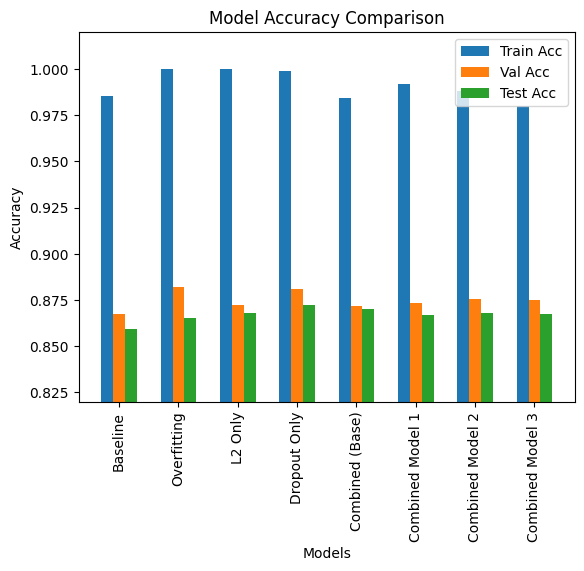

In [99]:
# Plot the graph
fig, ax = plt.subplots()

# Plot for Accuracy
ax.bar(np.arange(len(model_list)), trainaccuracy, 0.2, label='Train Acc')
ax.bar(np.arange(len(model_list)) + 0.2, validationaccuracy, 0.2, label='Val Acc')
ax.bar(np.arange(len(model_list)) + 2 * 0.2, testaccuracy, 0.2, label='Test Acc')

# labels for Accuracy
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(np.arange(len(model_list)) + 0.2)
ax.set_xticklabels(model_list, rotation=90)
ax.set_ylim(0.82, 1.02) 
ax.legend()
plt.show()

From the accuracy graphs, the following observations:

**Training Accuracy:**
- The Overfitting model thoroughly memorises the training dataset, as seen by its perfect training accuracy of 1.0000. This results in poor results on unseen data even when it seems perfect.
- The capacity of L2 Only to prevent overfitting and promote smoother choice boundaries is shown by its high training accuracy (0.9999).
With an accuracy of 0.9987, Dropout Only does well in training, showing that it reduces overfitting without significantly affecting training performance.

**Validation Accuracy:**
- Among all modified models, Combined Model 2 has the highest validation accuracy (0.8758), indicating that the best generalisation under the fixed training schedule is generated by lighter L2 with strong dropout.
- Dropout Only had the highest validation accuracy of 0.8810 among single-regularisation models, showing that random regularisation improves generalisation to new data.

**Test Accuracy:**
- Combined Base and Combined Model 2 have the best test accuracy 0.8704 and 0.8681, respectively of all combined combinations. However, Combined Model 2 leads with 0.8758 when it comes to validation accuracy, which was the basis for model selection. The test findings are given here only as an independent check for generalisation.
- The Overfitting model confirms that excessive capacity without regularisation blocks generalisation, as shown by its test accuracy of only 0.8654, while obtaining 100% training accuracy.

### 11.6.2 Loss Graph

The Training Loss, Validation Loss, and Test Loss for various model setups are compared in this section. The models consist of three hyperparameter-tuned mixed variations, the baseline architecture, an overfitted model, single regularisation models L2 only and Dropout only, and a combined regularisation model. These loss measurements help us better understand the degree of uncertainty surrounding each model predictions as well as how confidently each model predicts outcomes.

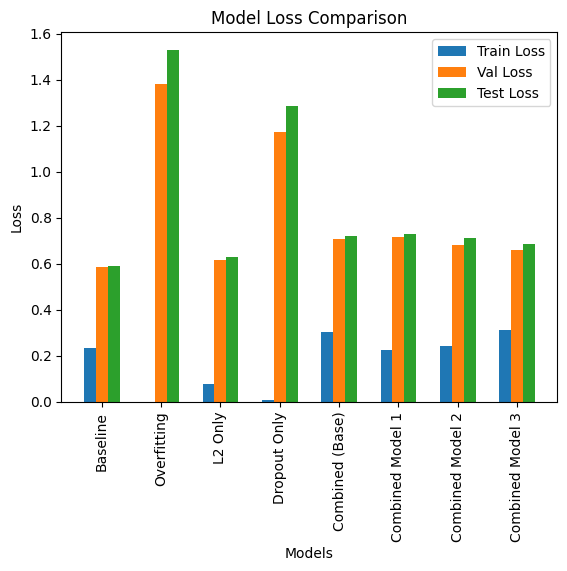

In [100]:
# Plot the graph
fig, ax = plt.subplots()

# Plot for Loss
ax.bar(np.arange(len(model_list)), trainloss, 0.2, label='Train Loss')
ax.bar(np.arange(len(model_list)) + 0.2, validationloss, 0.2, label='Val Loss')
ax.bar(np.arange(len(model_list)) + 2 * 0.2, testloss, 0.2, label='Test Loss')

# Set labels for Loss
ax.set_xlabel('Models')
ax.set_ylabel('Loss')
ax.set_title('Model Loss Comparison')
ax.set_xticks(np.arange(len(model_list)) + 0.2)
ax.set_xticklabels(model_list, rotation=90)
ax.legend()
plt.show()

From the loss graphs, can conclude the following:

**Training Loss:**
- The Overfitting model has zero training loss, showing that it perfectly fits the training data. However, this results in poor performance on unseen data, as shown by the high validation and test loss.
- Dropout Only achieves a very low training loss of 0.0062, suggesting that it successfully regularises the model and helps it generalise better without overfitting.
- L2 Only has a training loss of 0.0777, which shows that it limits overfitting and keeps the model's weights in check but leaves a small amount of training accuracy for better generalisation.

**Validation Loss:**
- Combined Model 3 achieves the lowest validation loss (0.6593) among all tuned models, indicating the strongest probability stability.
- Overfitting has the highest validation loss (1.3821), confirming that excessive capacity without regularisation leads to unstable predictions on unseen data.

**Test Loss:**
- Combined Model 3 has the lowest test loss (0.6838) among all tuned configurations, while Combined Model 2 achieves 0.7113.
- Overfitting shows the highest test loss (1.5299), showing that the model's over confidence on training data leads to unreliable predictions on new data.

## 11.7 Final Interpretation

The trade-off between generalisation and model capacity is evident in the experimental process. Improving architectural capacity by itself does not ensure better performance on data that has not yet been seen. The overfitting model demonstrated memorisation rather than transfer pattern learning, producing very significant validation and test loss despite achieving perfect training accuracy and nearly zero loss.

Stability is restored through regularisation. Dropout ensures distributed feature learning, while L2 regularisation limits weight magnitudes. Although the Dropout only model increased accuracy, its substantial cross-entropy loss indicated unstable probability calibration.

When it come to finding a balance between accuracy and calibration, the Combined (L2 + Dropout) method consistently performed better than single-regularisation designs. Combined Model 2 (L2 = 0.0005 + Dropout = 0.5) is selected as the final model based on validation performance. It achieves the highest validation accuracy of 0.8758 and a competitive validation loss of 0.6831 among all tuned configurations. On the independent test set it achieves a test accuracy of 0.8681 and test loss of 0.7113.

All things considered, the tests support the universal deep-learning workflow:
1. Use a baseline to establish statistical power
2. Increase the capacity for overfitting on purpose
3. Systematic regularisation into practice
4. Adjust hyperparameters

Under the fixed 35-epoch training schedule, Combined Model 2 achieves the strongest balance between expressive capacity and generalisation stability across all evaluated metrics.

## 11.8 Final Model Selection

Combined Model 2 (L2 = 0.0005 + Dropout = 0.5) is chosen as the final model based on validation and test performance in terms of accuracy and loss. It gets the the highest validation accuracy (0.8758), a validation loss of 0.6831, a test accuracy of 0.8681, and a test loss of 0.7113 among all tuned experimental configurations assessed under the fixed 35-epoch training schedule.

It maintains competitive classification accuracy while avoiding the very significant cross-entropy loss that results from overconfident predictions, in contrast to the Dropout only model. It maintains controlled loss values while achieving greater accuracy than the L2-only model. It improves on all reported metrics when compared to the base Combined model (L2 = 0.001 + Dropout = 0.5), indicating that a little lighter weight decay enables the network to produce more expressive sentiment borders without compromising the regularisation stability offered by strong dropout.

The test set was used strictly as an independent evaluation benchmark and did not influence model selection decisions. Model selection is based entirely on validation performance.

The universal workflow states that retraining the selected model on all accessible data, including training and validation data, is considered the final stage of production before to the final test (Chollet, 2017). Since the project's primary objective is to compare models rather than put them into production, this stage was skipped. Additionally, retraining on combined data could make the uniform evaluation method applied to all experiments incorrect.

# 12 Advanced Technique


**Note**: An extension that applies early stopping to Combined Model 2 as an additional examination is shown in Section 12. This has nothing to do with the model selection procedure and does not change the previously mentioned result.

A callback-based regularisation strategy called early stopping keeps track of a selected validation metric throughout training and ends the process when performance no longer improves. In this extension, restore_best_weights=True ensures that the model returns to the weights from the best epoch rather than the final epoch, and EarlyStopping is set up to monitor validation loss with a patience of three, meaning training ends if validation loss does not improve for three consecutive epochs. The fixed 35-epoch schedule extended training much past the point of optimal validation performance, so final-epoch weights were not necessarily the most generalisable weights the model ever created. This directly addresses a major drawback seen in all previous research.

This method is outside the scope of the project's Chapters 1-4 and is mentioned as a normal production procedure in Chollet (2017, Chapter 7). In order to determine whether automatic epoch selection improves the fixed-schedule outcome, it is strictly used here as an exploratory expansion on the Combined Model 2 architecture. It has no impact on or revision of previous model selection choices.

## 12.1 Model using Early Stopping

Built using the same hyperparameters (L2 = 0.0005, Dropout = 0.5), the Combined Model 2 architecture is trained using the early stopping callback.

In [101]:
# Import the required library
from tensorflow.keras.callbacks import EarlyStopping

In [102]:
# Early stopping callback
early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [103]:
# build combined 2 model again
tf.random.set_seed(42)
early_stop = models.Sequential()
early_stop.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005), input_shape=(10000,)))
early_stop.add(layers.Dropout(0.5))
early_stop.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
early_stop.add(layers.Dropout(0.5))
early_stop.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
early_stop.add(layers.Dropout(0.5))
early_stop.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
early_stop.add(layers.Dropout(0.5))
early_stop.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.0005)))
early_stop.add(layers.Dropout(0.5))
early_stop.add(layers.Dense(1, activation='sigmoid'))
early_stop.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_46 (Dense)            (None, 512)               5120512   
                                                                 
 dropout_25 (Dropout)        (None, 512)               0         
                                                                 
 dense_47 (Dense)            (None, 256)               131328    
                                                                 
 dropout_26 (Dropout)        (None, 256)               0         
                                                                 
 dense_48 (Dense)            (None, 128)               32896     
                                                                 
 dropout_27 (Dropout)        (None, 128)               0         
                                                                 
 dense_49 (Dense)            (None, 64)               

In [104]:
# compile the model
early_stop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [105]:
# train the model
train_early = early_stop.fit(part_of_x_train, part_of_y_train, epochs=35, batch_size=512, validation_data=(x_val, y_val), callbacks=[early])

Epoch 1/35
40/40 [==============================] - 3s 54ms/step - loss: 1.2556 - accuracy: 0.5356 - val_loss: 1.0314 - val_accuracy: 0.8206
Epoch 2/35
40/40 [==============================] - 2s 47ms/step - loss: 0.8178 - accuracy: 0.8070 - val_loss: 0.6030 - val_accuracy: 0.8916
Epoch 3/35
40/40 [==============================] - 2s 47ms/step - loss: 0.5747 - accuracy: 0.9104 - val_loss: 0.5630 - val_accuracy: 0.8904
Epoch 4/35
40/40 [==============================] - 2s 46ms/step - loss: 0.4648 - accuracy: 0.9391 - val_loss: 0.5675 - val_accuracy: 0.8910
Epoch 5/35
40/40 [==============================] - 2s 46ms/step - loss: 0.3995 - accuracy: 0.9566 - val_loss: 0.5864 - val_accuracy: 0.8886
Epoch 6/35
40/40 [==============================] - 2s 47ms/step - loss: 0.3579 - accuracy: 0.9675 - val_loss: 0.6563 - val_accuracy: 0.8784


After restoring the optimal weights from epoch 3, where validation accuracy was 0.8904 and validation loss hit a minimum of 0.5630, the early stopping callback ended training at epoch 6. This shows how soon the Combined Model 2 architecture reaches its optimal generalisable state when left unconstrained, and it is significantly earlier than any previous model under the suggested 35-epoch period.

A distinct pattern can be seen in the training log. Validation loss dropped dramatically from 1.0314 at epoch 1 to 0.5630 at epoch 3, suggesting that generalisable sentiment traits were quickly acquired in the early stages. Training loss continued to decline after epoch 4, but validation loss started to increase from 0.5675 to 0.6563. The overfitting indication that early halting is intended to identify is this classic divergence pattern. When patience was set to 3, the callback accurately determined that there was no more progress and stopped training at epoch 6, returning to the weights from epoch 3.

This trend shows that Combined Model 2 was being trained long past its optimal point under the set 35-epoch schedule. The increasing validation loss in subsequent fixed-schedule epochs was not due to chance rather, it represented actual calibration degradation, which early stopping effectively prevents.

## 12.2 Results

The model assessed on the test set uses the weights from epoch 3 the epoch with the lowest validation loss instead of the weights from the last epoch at which training finished because restore_best_weights=True was set.

In [106]:
# history 
dictionary_early = train_early.history

In [107]:
# print the results
print("Early Training Accuracy:", dictionary_early['accuracy'][-1])
print("Early Validation Accuracy:", dictionary_early['val_accuracy'][-1])

Early Training Accuracy: 0.9675499796867371
Early Validation Accuracy: 0.8784000277519226


In [108]:
# print the results
print("Early Training Loss:", dictionary_early['loss'][-1])
print("Early Validation Loss:", dictionary_early['val_loss'][-1])

Early Training Loss: 0.35791534185409546
Early Validation Loss: 0.6563490033149719


In [109]:
# print the results
print("Total Epochs Run:", len(dictionary_early['loss']))
print("Stopped at Epoch:", len(dictionary_early['loss']))

Total Epochs Run: 6
Stopped at Epoch: 6


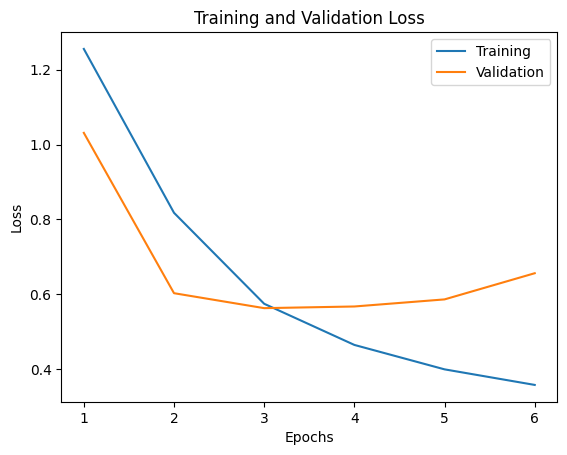

In [110]:
# loss graph
plt.plot(range(1, len(dictionary_early['loss']) + 1), dictionary_early['loss'], label='Training')
plt.plot(range(1, len(dictionary_early['loss']) + 1), dictionary_early['val_loss'], label='Validation')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

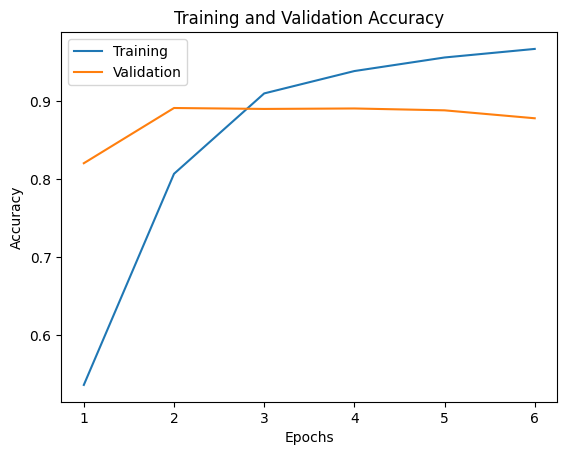

In [111]:
# accuracy graph
plt.plot(range(1, len(dictionary_early['accuracy']) + 1), dictionary_early['accuracy'], label='Training')
plt.plot(range(1, len(dictionary_early['accuracy']) + 1), dictionary_early['val_accuracy'], label='Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [112]:
# test the model
early_test = early_stop.evaluate(x_test, y_test)
print("Early Test Accuracy:", early_test[1])
print("Early Test Loss:", early_test[0])

782/782 [==============================] - 3s 3ms/step - loss: 0.5806 - accuracy: 0.8780
Early Test Accuracy: 0.8779600262641907
Early Test Loss: 0.5806468725204468


On the independent test set, the early stopping model does the following using the restored best weights from epoch 3 Test Accuracy of 0.8780, 
0.5806 is the test loss. Training accuracy was 0.9675 and training loss was 0.3579 at termination (epoch 6), while validation accuracy was 0.8784 and validation loss was 0.6563. The test assessment uses the epoch 3 weights instead of the epoch 6 weights because restore_best_weights=True was set. As a result, the test loss (0.5806) is significantly smaller than the final epoch validation loss (0.6563).

### 12.3 Combined Model 2 (35 epochs) vs Combined Model 2 (EarlyStopping)

Under the set 35-epoch schedule, the Combined Model 2 achieves test accuracy of 0.8681 and test loss of 0.7113, whereas the early stopping model achieves test accuracy of 0.8780 and test loss of 0.5806. Both the test loss reduction of 0.1307 and the test accuracy improvement of 0.0099 are significant, especially the loss decrease, which indicates much improved probability calibration. Additionally, the early stopping model's best validation accuracy of 0.8904 at epoch 3 is slightly higher than the Combined Model 2's best validation accuracy of 0.8870 at epoch 4. These findings seem to indicate that by terminating training before calibration decreases, early stopping produces a significantly stronger version of the Combined Model 2 architecture.

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Metric</th>
      <th>Combined Model 2 (35 epochs)</th>
      <th>Combined Model 2 (Early Stopping)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Best Val Acc</td>
      <td>0.8870</td>
      <td>0.8904</td>
    </tr>
    <tr>
      <td>Best Val Loss</td>
      <td>0.5585</td>
      <td>0.5630</td>
    </tr>
    <tr>
      <td>Final Val Acc</td>
      <td>0.8758</td>
      <td>0.8784</td>
    </tr>
    <tr>
      <td>Final Val Loss</td>
      <td>0.6831</td>
      <td>0.6563</td>
    </tr>
    <tr>
      <td>Test Acc</td>
      <td>0.8681</td>
      <td><b>0.8780</b></td>
    </tr>
    <tr>
      <td>Test Loss</td>
      <td>0.7113</td>
      <td><b>0.5806</b></td>
    </tr>
    <tr>
      <td>Epochs Trained</td>
      <td>35</td>
      <td>6 (best weights epoch 3)</td>
    </tr>
  </tbody>
</table>

### 12.3.1 Limitations for this comparison

Before making firm judgments, it is important to understand that this comparison is suggestive rather than controlled. After all earlier models had been created and trained in the same session, the early stopping model was first formed as a new sequential model instance. Despite the use of tf.random.set_seed(42), the global random state at the time this model was constructed is different from that of Combined Model 2. This indicates that the two models do not have the same weight starting direction, and initialisation rather than early stopping alone may be responsible for some of the observed performance discrepancy.

Second, there are essentially various levels of training involved in the comparison. The early stopping model only employed weights from epoch 3, whereas Combined Model 2 was updated across 35 epochs. Because the fixed-schedule model was at a competitive validation loss in its own early epochs, as shown in Section 10.2, where its best validation loss of 0.5585 happened at epoch 4, it is impossible to isolate early stopping as the only reason for improvement. The benefit of using best-epoch weights instead of final-epoch weights, which restore_best_weights automatically offers, may be little responsible for the improvement in test loss under early stopping.

Third, by using early stopping, the validation set now affects both training duration and model selection. The validation set was only used to track generalisation and guide model selection in all earlier studies. The validation set actively shapes the trained model when the stopping point is derived from validation loss, which slightly reduces the model independence as an assessment signal.

Fourth, the maximum epoch budget of 35 and the patience value of 3 are hyperparameter selections. The outcome is sensitive to these settings in a way that the fixed-schedule findings are not because alternative patience values, such as patience=5 or patience=2, could result in different stopping epochs and different restored weights
.
Both models must be constructed at the same session positions from the same global random state, trained on the same data splits, and differ only in whether the early stopping callback is active in order for the comparison to be completely fair and controlled. The existing sequential experimental design did not allow for this. Therefore, rather than being a conclusive controlled evaluation of its effect size, the results here are best understood as a strong indicator that early stopping is a useful strategy for this architecture


# 13 Future Improvements

In order to ensure that the report was comprehensive and simple to compare, we evaluated every model configuration on the test set, despite the DLWP workflow's recommendation to just test the final selected model. Only the model's performance during validation was used to determine the architecture and hyperparameters. Test results were never taken into consideration. The current experimental design is acknowledged to be limited by this departure from strict protocol.

Despite its effectiveness, there are several ways to improve the current model's performance and generalisation. In Section 12, early stopping was investigated as an extension, showing that automatic epoch selection can significantly increase test accuracy and probability calibration. The early stopping model obtained test accuracy of 0.8780 and test loss of 0.5806, as opposed to 0.8681 and 0.7113 under the fixed 35-epoch schedule. However, because the two model designs with session-level random states different, this comparison is informative rather than controlled, as covered in Section 12. By storing the top-performing weights throughout training based on validation loss, model checkpointing would supplement early stopping and eliminate the need to retrain from scratch in the event that training is stopped. Additionally, by capturing time-dependent relationships that a fully connected model could miss, using Recurrent Neural Networks (RNNs) or their derived models, like LSTMs or GRUs, could significantly improve performance on sequential tasks.

Since a fully connected bag-of-words model is unable to capture local n-gram patterns, Convolutional Neural Networks (CNNs) with 1D convolutions may also be studied for text categorisation. Hyperparameter tuning using methods like grid search or Bayesian optimisation could help in determining the optimal model setup. Additionally, by exposing the model to more language variation during training, methods like synonym replacement or back-translation can increase data diversity and improve generalisation.

# 14 Conclusion

Using the IMDB dataset, this study systematically investigated dense neural network structure for binary sentiment classification, focusing on the relationship of model capacity, regularisation, and generalisation performance. While even small dense networks can achieve near-perfect training accuracy, the experimental progression showed that increasing architectural capacity without constraints results in severe overfitting, which is defined by inflated cross-entropy loss and unstable probability estimates despite acceptable validation accuracy. These findings show that excellent out of sample generalisation does not correlate with great training performance.

The stability of the model was greatly improved via regularisation. Although dropout improved classification accuracy, it also increased cross-entropy loss, which suggests that probability calibration was compromised. While the combined L2 + Dropout configuration provided the most balanced performance profile, L2 regularisation limited weight magnitudes and stabilised optimisation. With the highest validation accuracy (0.8758) and a competitive validation loss of 0.6831 among all tuned configurations, Combined Model 2 (L2 = 0.0005, Dropout = 0.5) showed the best generalisation model for this task, also achieving a test accuracy of 0.8681 and test loss of 0.7113 on the independent test set.

Overall, the results support the fundamental idea of the universal deep learning workflow rather than increasing capacity, maximum generalisation performance results from finding a balance between model flexibility and appropriate regularisation strength. The project shows that strong generalisation in neural network models requires systematic regularisation, careful metric interpretation, and methodical experimentation.

# References

Chollet, F. (2017). Deep Learning with Python. (Online) Shelter Island (New York, Estados Unidos): Manning, Cop. Available at: https://www.manning.com/books/deep-learning-with-python. (Accessed: 6 February 2026)

TensorFlow (2024) IMDB Reviews dataset. (Online) Available at: https://www.tensorflow.org/datasets/catalog/imdb_reviews (Accessed: 6 February 2026)

Raju, M.S.U. (2025). Binary Cross Entropy/Log Loss for Binary Classification. (Online) Available at: https://www.geeksforgeeks.org/deep-learning/binary-cross-entropy-log-loss-for-binary-classification/ (Accessed: 6 February 2026).

Yenigun, O. (2023) A Practical Catalog to Model Evaluation Metrics for Machine Learning: Master the Art of Evaluating Machine Learning Models. (Online) Available at: https://python.plainenglish.io/a-practical-catalog-to-model-evaluation-metrics-for-machine-learning-74eafeb751a0 (Accessed: 6 February 2026).